In [8]:
import math
import pandas as pd

# Rutas
banks_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.parquet"
index_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.parquet"
output_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"

# ============
# 1. Cargar
# ============
df_banks = pd.read_parquet(banks_path)
df_index = pd.read_parquet(index_path)

# Bancos: date, ticket, price_adj, ...
# Índice: date, sp_financial

df_banks['date'] = pd.to_datetime(df_banks['date'])
df_index['date'] = pd.to_datetime(df_index['date'])

# ==========================
# 2. Rendimientos bancos
# ==========================
df_banks = df_banks.sort_values(['ticket', 'date'])

df_banks['ret'] = (
    df_banks
    .groupby('ticket')['price_adj']
    .apply(lambda x: (x / x.shift(1)).apply(
        lambda r: math.log(r) if pd.notna(r) and r > 0 else pd.NA
    ))
    .reset_index(level=0, drop=True)
)

# ==========================
# 3. Rendimientos índice
# ==========================
df_index = df_index.sort_values('date')

df_index['ret_mkt'] = df_index['sp_financial'].pct_change().apply(
    lambda r: math.log(1 + r) if pd.notna(r) and r > -1 else pd.NA
)

df_index_ret = df_index[['date', 'ret_mkt']].dropna().drop_duplicates('date')

# ==========================
# 4. Unir bancos + índice
# ==========================
panel = pd.merge(df_banks, df_index_ret, on='date', how='inner')
panel = panel.dropna(subset=['ret', 'ret_mkt'])

# Asegurarnos de que ticket sigue siendo columna
panel = panel.reset_index(drop=True)

# ==========================
# 5. MES estático global
# ==========================
p = 0.05
threshold_global = panel['ret_mkt'].quantile(p)
panel['is_crisis_global'] = panel['ret_mkt'] < threshold_global

mes_static = (
    panel.loc[panel['is_crisis_global']]
    .groupby('ticket')['ret']
    .mean()
    .rename('MES_static')
    .reset_index()
)

# ==========================
# 6. MES dinámico (ventana 24 meses) SIN groupby.apply
# ==========================
window = 24

# Umbral dinámico del mercado por fecha
idx_sorted = (
    panel[['date', 'ret_mkt']]
    .drop_duplicates()
    .sort_values('date')
)

idx_sorted['mkt_thr_rolling'] = (
    idx_sorted['ret_mkt']
    .rolling(window=window, min_periods=int(window/2))
    .quantile(p)
)

panel = panel.merge(idx_sorted[['date', 'mkt_thr_rolling']], on='date', how='left')
panel['is_crisis_rolling'] = panel['ret_mkt'] < panel['mkt_thr_rolling']

# Ahora calculamos MES_dynamic con rolling dentro de cada banco:
# idea: para cada banco, una rolling(window) sobre las filas, pero usando sólo las filas donde is_crisis_rolling es True

def mes_rolling_bank(g):
    g = g.sort_values('date')
    # para cada fila, queremos la media de 'ret' en los últimos 'window' meses donde is_crisis_rolling=True
    # truco: usamos un rolling sobre el índice y filtramos dentro de la función
    def mes_func(sub):
        sub = sub[sub['is_crisis_rolling']]
        if len(sub) == 0:
            return pd.NA
        else:
            return sub['ret'].mean()

    g['MES_dynamic'] = (
        g[['ret', 'is_crisis_rolling']]
        .rolling(window=window, min_periods=1)
        .apply(lambda x: mes_func(
            pd.DataFrame({'ret': x[:,0], 'is_crisis_rolling': x[:,1].astype(bool)})
        ), raw=True)
        .reset_index(level=0, drop=True)
    )
    return g



In [9]:
import pandas as pd

output_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"

# Cargar panel con MES_dynamic ya calculado
panel = pd.read_parquet(output_path)

# Comprobar que está la columna 'ticket'
print(panel.columns)

# Calcular MES_static (cola 5% global) solo a partir de los datos guardados
p = 0.05
threshold_global = panel['ret_mkt'].quantile(p)
panel['is_crisis_global'] = panel['ret_mkt'] < threshold_global

mes_static = (
    panel.loc[panel['is_crisis_global']]
    .groupby('ticket')['ret']
    .mean()
    .rename('MES_static')
    .reset_index()
)

# Hacer el merge con cuidado, asegurando que 'ticket' es columna en ambos
panel = panel.merge(mes_static, on='ticket', how='left')

# Guardar de nuevo (o en otro archivo si prefieres)
panel.to_parquet(output_path, index=False)
print("Archivo con MES_dynamic y MES_static guardado en:", output_path)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\tfg_finance\\mi_proyecto_datos\\local_db\\processed\\indices\\bank_list_MES-monthly_withMES.parquet'

In [10]:
import math
import pandas as pd

# ============
# 1. Rutas
# ============
banks_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.parquet"
index_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.parquet"
output_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"

# ============
# 2. Cargar
# ============
df_banks = pd.read_parquet(banks_path)
df_index = pd.read_parquet(index_path)

# df_banks: date, ticket, price_adj, ...
# df_index: date, sp_financial

df_banks['date'] = pd.to_datetime(df_banks['date'])
df_index['date'] = pd.to_datetime(df_index['date'])

# ==========================
# 3. Rendimientos bancos
# ==========================
df_banks = df_banks.sort_values(['ticket', 'date'])

df_banks['ret'] = (
    df_banks
    .groupby('ticket')['price_adj']
    .apply(lambda x: (x / x.shift(1)).apply(
        lambda r: math.log(r) if pd.notna(r) and r > 0 else pd.NA
    ))
    .reset_index(level=0, drop=True)
)

# ==========================
# 4. Rendimientos índice
# ==========================
df_index = df_index.sort_values('date')

df_index['ret_mkt'] = df_index['sp_financial'].pct_change().apply(
    lambda r: math.log(1 + r) if pd.notna(r) and r > -1 else pd.NA
)

df_index_ret = df_index[['date', 'ret_mkt']].dropna().drop_duplicates('date')

# ==========================
# 5. Unir bancos + índice
# ==========================
panel = pd.merge(df_banks, df_index_ret, on='date', how='inner')
panel = panel.dropna(subset=['ret', 'ret_mkt'])
panel = panel.reset_index(drop=True)

# ==========================
# 6. MES dinámico banco-mes
# ==========================
p = 0.05
window = 24

# Umbral dinámico del mercado
idx_sorted = (
    panel[['date', 'ret_mkt']]
    .drop_duplicates()
    .sort_values('date')
)

idx_sorted['mkt_thr_rolling'] = (
    idx_sorted['ret_mkt']
    .rolling(window=window, min_periods=int(window/2))
    .quantile(p)
)

panel = panel.merge(idx_sorted[['date', 'mkt_thr_rolling']], on='date', how='left')
panel['is_crisis_rolling'] = panel['ret_mkt'] < panel['mkt_thr_rolling']

def compute_mes_dynamic(group, window=24):
    group = group.sort_values('date').reset_index(drop=True)
    rets = group['ret'].to_numpy()
    crisis_flags = group['is_crisis_rolling'].to_numpy()

    mes_values = []
    n = len(group)
    for i in range(n):
        start = max(0, i - window + 1)
        mask = crisis_flags[start:i+1]
        if mask.sum() > 0:
            mes_values.append(rets[start:i+1][mask].mean())
        else:
            mes_values.append(pd.NA)
    group['MES_dynamic'] = mes_values
    return group

panel = panel.groupby('ticket', group_keys=False).apply(compute_mes_dynamic, window=window)
panel = panel.reset_index(drop=True)

# ==========================
# 7. Guardar resultado
# ==========================
panel.to_parquet(output_path, index=False)
print("Archivo con MES_dynamic guardado en:")
print(output_path)

C:\Users\oscar\AppData\Local\Temp\ipykernel_27900\1573871359.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel = panel.groupby('ticket', group_keys=False).apply(compute_mes_dynamic, window=window)


Archivo con MES_dynamic guardado en:
D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet


In [11]:
panel_mes = pd.read_parquet(output_path)
panel_mes.head()

,date,ticket,price_adj,rssd_id,Asset_share_100,Market_Cap_bll,ret,ret_mkt,mkt_thr_rolling,is_crisis_rolling


In [12]:
panel_mes.columns
panel_mes.head()

,date,ticket,price_adj,rssd_id,Asset_share_100,Market_Cap_bll,ret,ret_mkt,mkt_thr_rolling,is_crisis_rolling


In [13]:
import numpy as np
import pandas as pd

# partimos de panel_mes tal como lo tienes cargado
panel_mes = panel_mes.sort_values(['ticket', 'date']).reset_index(drop=True)

window = 24  # meses
p = 0.05     # ya has usado este p para mkt_thr_rolling

def compute_mes_dynamic_from_existing(group, window=24):
    group = group.sort_values('date').reset_index(drop=True)
    rets = group['ret'].to_numpy()
    crisis_flags = group['is_crisis_rolling'].to_numpy()

    mes_values = []
    n = len(group)
    for i in range(n):
        start = max(0, i - window + 1)
        mask = crisis_flags[start:i+1]
        if mask.sum() > 0:
            mes_values.append(rets[start:i+1][mask].mean())
        else:
            mes_values.append(np.nan)
    group['MES_dynamic'] = mes_values
    return group

panel_mes = (
    panel_mes
    .groupby('ticket', group_keys=False)
    .apply(compute_mes_dynamic_from_existing, window=window)
    .reset_index(drop=True)
)

# comprobar que está la columna
print(panel_mes.columns)

# si todo está bien, volver a guardar
output_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"
panel_mes.to_parquet(output_path, index=False)

C:\Users\oscar\AppData\Local\Temp\ipykernel_27900\1640851674.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_mes_dynamic_from_existing, window=window)


Index(['date', 'ticket', 'price_adj', 'rssd_id', 'Asset_share_100',
       'Market_Cap_bll', 'ret', 'ret_mkt', 'mkt_thr_rolling',
       'is_crisis_rolling'],
      dtype='object')


In [14]:
import numpy as np
import pandas as pd

# Asegurarnos de que está ordenado
panel_mes = panel_mes.sort_values(['ticket', 'date']).reset_index(drop=True)

window = 24  # meses

mes_list = []  # aquí guardaremos los resultados fila a fila

for ticket, g in panel_mes.groupby('ticket', sort=False):
    g = g.sort_values('date').reset_index(drop=True)
    rets = g['ret'].to_numpy()
    crisis_flags = g['is_crisis_rolling'].to_numpy()

    mes_values = []
    n = len(g)
    for i in range(n):
        start = max(0, i - window + 1)
        mask = crisis_flags[start:i+1]
        if mask.sum() > 0:
            mes_values.append(rets[start:i+1][mask].mean())
        else:
            mes_values.append(np.nan)

    # guardamos en la misma orden de g
    mes_list.extend(mes_values)

# Añadir la columna al DataFrame original
panel_mes['MES_dynamic'] = mes_list

print(panel_mes.columns)
print(panel_mes.head())

Index(['date', 'ticket', 'price_adj', 'rssd_id', 'Asset_share_100',
       'Market_Cap_bll', 'ret', 'ret_mkt', 'mkt_thr_rolling',
       'is_crisis_rolling', 'MES_dynamic'],
      dtype='object')
Empty DataFrame
Columns: [date, ticket, price_adj, rssd_id, Asset_share_100, Market_Cap_bll, ret, ret_mkt, mkt_thr_rolling, is_crisis_rolling, MES_dynamic]
Index: []


In [15]:
output_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"
panel_mes.to_parquet(output_path, index=False)

In [16]:
panel_mes.columns
panel_mes.head()

,date,ticket,price_adj,rssd_id,Asset_share_100,Market_Cap_bll,ret,ret_mkt,mkt_thr_rolling,is_crisis_rolling,MES_dynamic


In [17]:
import pandas as pd

# partimos del panel mensual que ya tienes
# si hiciera falta, lo cargamos:
# panel_mes = pd.read_parquet(output_path)

# Asegurarnos de que la fecha es datetime
panel_mes['date'] = pd.to_datetime(panel_mes['date'])

# Crear variables de año y trimestre
panel_mes['year'] = panel_mes['date'].dt.year
panel_mes['quarter'] = panel_mes['date'].dt.quarter

# Agregar MES_dynamic a nivel banco-trimestre
# opción 1: media de los MES_dynamic mensuales del trimestre
mes_trimestral = (
    panel_mes
    .groupby(['ticket', 'year', 'quarter'], as_index=False)
    .agg(
        MES_q_mean=('MES_dynamic', 'mean'),      # media trimestral
        MES_q_last=('MES_dynamic', 'last'),      # último mes del trimestre (por si quieres)
        n_months=('MES_dynamic', 'count')        # cuántos meses válidos entran
    )
)

# Si quieres quedarte solo con una medida (por ejemplo la media):
mes_trimestral = mes_trimestral.rename(columns={'MES_q_mean': 'MES_trimestral'})
mes_trimestral = mes_trimestral.drop(columns=['MES_q_last'])

print(mes_trimestral.head())

Empty DataFrame
Columns: [ticket, year, quarter, MES_trimestral, n_months]
Index: []


In [18]:
import pandas as pd

# Si hace falta, cargar el parquet con MES_dynamic
# panel_mes = pd.read_parquet(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet")

panel_mes['date'] = pd.to_datetime(panel_mes['date'])

# Año y trimestre
panel_mes['year'] = panel_mes['date'].dt.year
panel_mes['quarter'] = panel_mes['date'].dt.quarter

# Agregar por rssd_id-year-quarter
mes_trimestral = (
    panel_mes
    .groupby(['rssd_id', 'year', 'quarter'], as_index=False)
    .agg(
        MES_trimestral=('MES_dynamic', 'mean'),
        n_months=('MES_dynamic', 'count')
    )
)

print(mes_trimestral.head())

Empty DataFrame
Columns: [rssd_id, year, quarter, MES_trimestral, n_months]
Index: []


In [20]:
import pandas as pd

panel_trim_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv"

panel_trim = pd.read_csv(panel_trim_path)

panel_trim['date'] = pd.to_datetime(panel_trim['date'])
panel_trim['year'] = panel_trim['date'].dt.year
panel_trim['quarter'] = panel_trim['date'].dt.quarter

print(panel_trim.columns)
print(panel_trim[['id_rssd', 'date', 'year', 'quarter']].head())
mes_trimestral = (
    panel_mes
    .groupby(['rssd_id', 'year', 'quarter'], as_index=False)
    .agg(
        MES_trimestral=('MES_dynamic', 'mean'),
        n_months=('MES_dynamic', 'count')
    )
)

print(mes_trimestral.head())

Empty DataFrame
Columns: [rssd_id, year, quarter, MES_trimestral, n_months]
Index: []


In [22]:
import pandas as pd

panel_trim_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv"

panel_trim = pd.read_csv(panel_trim_path)

panel_trim['date'] = pd.to_datetime(panel_trim['date'])
panel_trim['year'] = panel_trim['date'].dt.year
panel_trim['quarter'] = panel_trim['date'].dt.quarter

print(panel_trim.columns)
print(panel_trim[['id_rssd', 'date', 'year', 'quarter']].head())

Index(['id_rssd', 'date', 'CAR', 'LIQ', 'NPL', 'CIL', 'HOL', 'WFUND', 'ROA',
       'year', 'quarter'],
      dtype='object')
   id_rssd       date  year  quarter
0       37 1996-03-31  1996        1
1       37 1996-06-30  1996        2
2       37 1996-09-30  1996        3
3       37 1996-12-31  1996        4
4       37 1997-03-31  1997        1


In [23]:
# partimos de panel_mes con MES_dynamic y columna id_rssd
panel_mes['date'] = pd.to_datetime(panel_mes['date'])
panel_mes['year'] = panel_mes['date'].dt.year
panel_mes['quarter'] = panel_mes['date'].dt.quarter

mes_trimestral = (
    panel_mes
    .groupby(['id_rssd', 'year', 'quarter'], as_index=False)
    .agg(
        MES_trimestral=('MES_dynamic', 'mean'),
        n_months=('MES_dynamic', 'count')
    )
)

print(mes_trimestral.head())

KeyError: 'id_rssd'

In [24]:
panel_mes.columns
panel_mes[['date']].head()

,date


In [25]:
print(panel_mes.columns.tolist())
panel_mes.head()

['date', 'ticket', 'price_adj', 'rssd_id', 'Asset_share_100', 'Market_Cap_bll', 'ret', 'ret_mkt', 'mkt_thr_rolling', 'is_crisis_rolling', 'MES_dynamic', 'year', 'quarter']


,date,ticket,price_adj,rssd_id,Asset_share_100,Market_Cap_bll,ret,ret_mkt,mkt_thr_rolling,is_crisis_rolling,MES_dynamic,year,quarter


In [26]:
import pandas as pd

# partimos de panel_mes ya en memoria
# renombrar rssd_id -> id_rssd para que coincida con el panel trimestral
panel_mes = panel_mes.rename(columns={'rssd_id': 'id_rssd'})

# (ya tienes year y quarter, pero por si acaso:)
panel_mes['date'] = pd.to_datetime(panel_mes['date'])
panel_mes['year'] = panel_mes['date'].dt.year
panel_mes['quarter'] = panel_mes['date'].dt.quarter

mes_trimestral = (
    panel_mes
    .groupby(['id_rssd', 'year', 'quarter'], as_index=False)
    .agg(
        MES_trimestral=('MES_dynamic', 'mean'),
        n_months=('MES_dynamic', 'count')
    )
)

print(mes_trimestral.head())

Empty DataFrame
Columns: [id_rssd, year, quarter, MES_trimestral, n_months]
Index: []


In [27]:
panel_trim_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv"
panel_trim = pd.read_csv(panel_trim_path)

panel_trim['date'] = pd.to_datetime(panel_trim['date'])
panel_trim['year'] = panel_trim['date'].dt.year
panel_trim['quarter'] = panel_trim['date'].dt.quarter

print(panel_trim.columns)
print(panel_trim[['id_rssd', 'date', 'year', 'quarter']].head())

Index(['id_rssd', 'date', 'CAR', 'LIQ', 'NPL', 'CIL', 'HOL', 'WFUND', 'ROA',
       'year', 'quarter'],
      dtype='object')
   id_rssd       date  year  quarter
0       37 1996-03-31  1996        1
1       37 1996-06-30  1996        2
2       37 1996-09-30  1996        3
3       37 1996-12-31  1996        4
4       37 1997-03-31  1997        1


In [28]:
panel_trim_mes = panel_trim.merge(
    mes_trimestral[['id_rssd', 'year', 'quarter', 'MES_trimestral']],
    on=['id_rssd', 'year', 'quarter'],
    how='left'
)

print(panel_trim_mes[['id_rssd', 'date', 'year', 'quarter', 'MES_trimestral']].head())
print(panel_trim_mes['MES_trimestral'].describe())

output_csv = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996_withMES.csv"
panel_trim_mes.to_csv(output_csv, index=False)
print("Archivo trimestral con MES guardado en:", output_csv)

   id_rssd       date  year  quarter  MES_trimestral
0       37 1996-03-31  1996        1             NaN
1       37 1996-06-30  1996        2             NaN
2       37 1996-09-30  1996        3             NaN
3       37 1996-12-31  1996        4             NaN
4       37 1997-03-31  1997        1             NaN
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: MES_trimestral, dtype: float64
Archivo trimestral con MES guardado en: D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996_withMES.csv


In [29]:
print(mes_trimestral.shape)
print(mes_trimestral.head())
print(mes_trimestral['MES_trimestral'].describe())
print(mes_trimestral[['id_rssd', 'year', 'quarter']].drop_duplicates().head())

(0, 5)
Empty DataFrame
Columns: [id_rssd, year, quarter, MES_trimestral, n_months]
Index: []
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: MES_trimestral, dtype: float64
Empty DataFrame
Columns: [id_rssd, year, quarter]
Index: []


In [30]:
print(panel_mes.columns.tolist())
panel_mes.head()

['date', 'ticket', 'price_adj', 'id_rssd', 'Asset_share_100', 'Market_Cap_bll', 'ret', 'ret_mkt', 'mkt_thr_rolling', 'is_crisis_rolling', 'MES_dynamic', 'year', 'quarter']


,date,ticket,price_adj,id_rssd,Asset_share_100,Market_Cap_bll,ret,ret_mkt,mkt_thr_rolling,is_crisis_rolling,MES_dynamic,year,quarter


In [31]:
panel_mes = panel_mes.rename(columns={'rssd_id': 'id_rssd'})
print(panel_mes.columns.tolist())

['date', 'ticket', 'price_adj', 'id_rssd', 'Asset_share_100', 'Market_Cap_bll', 'ret', 'ret_mkt', 'mkt_thr_rolling', 'is_crisis_rolling', 'MES_dynamic', 'year', 'quarter']


In [32]:
panel_mes['date'] = pd.to_datetime(panel_mes['date'])
panel_mes['year'] = panel_mes['date'].dt.year
panel_mes['quarter'] = panel_mes['date'].dt.quarter

mes_trimestral = (
    panel_mes
    .groupby(['id_rssd', 'year', 'quarter'], as_index=False)
    .agg(
        MES_trimestral=('MES_dynamic', 'mean'),
        n_months=('MES_dynamic', 'count')
    )
)

print(mes_trimestral.shape)
print(mes_trimestral.head())
print(mes_trimestral['MES_trimestral'].describe())

(0, 5)
Empty DataFrame
Columns: [id_rssd, year, quarter, MES_trimestral, n_months]
Index: []
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: MES_trimestral, dtype: float64


In [33]:
print(panel_mes['MES_dynamic'].describe())
print(panel_mes[['id_rssd', 'year', 'quarter']].drop_duplicates().head())
print(panel_mes[['id_rssd', 'year', 'quarter']].isna().mean())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: MES_dynamic, dtype: float64
Empty DataFrame
Columns: [id_rssd, year, quarter]
Index: []
id_rssd   NaN
year      NaN
quarter   NaN
dtype: float64


In [1]:
import math
import numpy as np
import pandas as pd

# ============
# Rutas
# ============
banks_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.parquet"
index_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.parquet"
output_panel_mes = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet"

# ============
# 1. Cargar
# ============
df_banks = pd.read_parquet(banks_path)
df_index = pd.read_parquet(index_path)

# df_banks: date, ticket, price_adj, rssd_id, ...
# df_index: date, sp_financial

df_banks['date'] = pd.to_datetime(df_banks['date'])
df_index['date'] = pd.to_datetime(df_index['date'])

# ============
# 2. Rendimientos bancos
# ============
df_banks = df_banks.sort_values(['ticket', 'date'])

df_banks['ret'] = (
    df_banks
    .groupby('ticket')['price_adj']
    .apply(lambda x: (x / x.shift(1)).apply(
        lambda r: math.log(r) if pd.notna(r) and r > 0 else np.nan
    ))
    .reset_index(level=0, drop=True)
)

# ============
# 3. Rendimientos índice
# ============
df_index = df_index.sort_values('date')

df_index['ret_mkt'] = df_index['sp_financial'].pct_change().apply(
    lambda r: math.log(1 + r) if pd.notna(r) and r > -1 else np.nan
)

df_index_ret = df_index[['date', 'ret_mkt']].dropna().drop_duplicates('date')

# ============
# 4. Unir bancos + índice
# ============
panel_mes = pd.merge(df_banks, df_index_ret, on='date', how='inner')
panel_mes = panel_mes.dropna(subset=['ret', 'ret_mkt']).reset_index(drop=True)

# ============
# 5. Marcar crisis rolling (24 meses, p=5%)
# ============
p = 0.05
window = 24

idx_sorted = (
    panel_mes[['date', 'ret_mkt']]
    .drop_duplicates()
    .sort_values('date')
)

idx_sorted['mkt_thr_rolling'] = (
    idx_sorted['ret_mkt']
    .rolling(window=window, min_periods=int(window/2))
    .quantile(p)
)

panel_mes = panel_mes.merge(idx_sorted[['date', 'mkt_thr_rolling']], on='date', how='left')
panel_mes['is_crisis_rolling'] = panel_mes['ret_mkt'] < panel_mes['mkt_thr_rolling']

# ============
# 6. Calcular MES_dynamic explícitamente (bucle por ticket)
# ============
panel_mes = panel_mes.sort_values(['ticket', 'date']).reset_index(drop=True)

mes_values_all = []

for ticket, g in panel_mes.groupby('ticket', sort=False):
    g = g.sort_values('date').reset_index(drop=True)
    rets = g['ret'].to_numpy()
    crisis = g['is_crisis_rolling'].to_numpy()

    mes_vals = []
    n = len(g)
    for i in range(n):
        start = max(0, i - window + 1)
        mask = crisis[start:i+1]
        if mask.sum() > 0:
            mes_vals.append(rets[start:i+1][mask].mean())
        else:
            mes_vals.append(np.nan)

    mes_values_all.extend(mes_vals)

panel_mes['MES_dynamic'] = mes_values_all

print(panel_mes['MES_dynamic'].describe())  # Aquí deberías ver count>0 y valores no NaN

panel_mes.to_parquet(output_panel_mes, index=False)
print("Panel mensual con MES_dynamic guardado en:", output_panel_mes)

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: MES_dynamic, dtype: float64
Panel mensual con MES_dynamic guardado en: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-monthly_withMES.parquet


In [2]:
import pandas as pd
from pathlib import Path

# Carpeta de salida
out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices")
out_dir.mkdir(parents=True, exist_ok=True)

# Guardar con los nombres indicados
sp_df.to_csv(out_dir / "spfinancial_mensual.csv", index=False)
banks_df.to_csv(out_dir / "banks_list_mensual.csv", index=False)

print("Guardado:", out_dir / "spfinancial_mensual.csv")
print("Guardado:", out_dir / "banks_list_mensual.csv")

NameError: name 'sp_df' is not defined

In [3]:
import pandas as pd
from pathlib import Path

# Rutas de los Parquet
parquet_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.parquet")
parquet_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.parquet")

# Leer los Parquet
sp_df    = pd.read_parquet(parquet_sp)
banks_df = pd.read_parquet(parquet_banks)

# Rutas de salida CSV (misma carpeta, mismo nombre base)
csv_sp    = parquet_sp.with_suffix(".csv")
csv_banks = parquet_banks.with_suffix(".csv")

# Guardar como CSV
sp_df.to_csv(csv_sp, index=False)
banks_df.to_csv(csv_banks, index=False)

print("Guardado:", csv_sp)
print("Guardado:", csv_banks)

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv
Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv


In [4]:
import pandas as pd
from pathlib import Path

path = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")

df = pd.read_csv(path)

# Nombres de columnas y tipos de datos
print(df.dtypes)

# O más completo: número de filas, columnas, tipos y memoria
df.info()

date                object
ticket              object
price_adj          float64
rssd_id              int64
Asset_share_100    float64
Market_Cap_bll     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15192 entries, 0 to 15191
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             15192 non-null  object 
 1   ticket           15192 non-null  object 
 2   price_adj        15192 non-null  float64
 3   rssd_id          15192 non-null  int64  
 4   Asset_share_100  15192 non-null  float64
 5   Market_Cap_bll   15192 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 712.3+ KB


In [5]:
import pandas as pd
from pathlib import Path

# 1. Leer el CSV
path = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")

df = pd.read_csv(path)

# 2. Convertir 'date' a datetime (viene como object)
df["date"] = pd.to_datetime(df["date"])


# 4. Calcular retorno mensual por banco
# pct_change() dentro de cada rssd_id: (P_t - P_{t-1}) / P_{t-1}
df["return_mes"] = (
    df.groupby("rssd_id")["price_adj"]
    .pct_change()
)

# 5. Comprobación rápida
print(df[["rssd_id", "date", "price_adj", "return_mes"]].head(20))
print(df["return_mes"].describe())

    rssd_id       date  price_adj  return_mes
0   1022764 1996-01-01  73.968933         NaN
1   1022764 1996-02-01  70.016357   -0.053436
2   1022764 1996-03-01  76.792152    0.096774
3   1022764 1996-04-01  71.691902   -0.066416
4   1022764 1996-05-01  71.976387    0.003968
5   1022764 1996-06-01  73.967842    0.027668
6   1022764 1996-07-01  65.352364   -0.116476
7   1022764 1996-08-01  69.938477    0.070175
8   1022764 1996-09-01  66.498894   -0.049180
9   1022764 1996-10-01  70.233116    0.056155
10  1022764 1996-11-01  68.209892   -0.028807
11  1022764 1996-12-01  68.787964    0.008475
12  1022764 1997-01-01  68.769379   -0.000270
13  1022764 1997-02-01  74.597282    0.084746
14  1022764 1997-03-01  77.802643    0.042969
15  1022764 1997-04-01  79.835876    0.026133
16  1022764 1997-05-01  83.945091    0.051471
17  1022764 1997-06-01  87.467270    0.041958
18  1022764 1997-07-01  84.520561   -0.033689
19  1022764 1997-08-01  87.475815    0.034965
count    15149.000000
mean        

In [6]:
out_path = Path(
    r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv"
)
df.to_csv(out_path, index=False)
print("Guardado:", out_path)

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv


In [7]:
# 5. Retorno trimestral: precio actual vs precio de hace 3 meses
#    (P_t - P_{t-3}) / P_{t-3}
df["return_q"] = (
    df.groupby("rssd_id")["price_adj"]
    .pct_change(periods=3)
)

# 6. Retorno anual: precio actual vs precio de hace 12 meses
#    (P_t - P_{t-12}) / P_{t-12}
df["return_anual"] = (
    df.groupby("rssd_id")["price_adj"]
    .pct_change(periods=12)
)

# 7. Comprobación rápida
print(df[["rssd_id", "date", "price_adj", "return_mes", "return_q", "return_anual"]].head(20))
print(df[["return_mes", "return_q", "return_anual"]].describe())

    rssd_id       date  price_adj  return_mes  return_q  return_anual
0   1022764 1996-01-01  73.968933         NaN       NaN           NaN
1   1022764 1996-02-01  70.016357   -0.053436       NaN           NaN
2   1022764 1996-03-01  76.792152    0.096774       NaN           NaN
3   1022764 1996-04-01  71.691902   -0.066416 -0.030784           NaN
4   1022764 1996-05-01  71.976387    0.003968  0.027994           NaN
5   1022764 1996-06-01  73.967842    0.027668 -0.036779           NaN
6   1022764 1996-07-01  65.352364   -0.116476 -0.088428           NaN
7   1022764 1996-08-01  69.938477    0.070175 -0.028314           NaN
8   1022764 1996-09-01  66.498894   -0.049180 -0.100976           NaN
9   1022764 1996-10-01  70.233116    0.056155  0.074684           NaN
10  1022764 1996-11-01  68.209892   -0.028807 -0.024716           NaN
11  1022764 1996-12-01  68.787964    0.008475  0.034423           NaN
12  1022764 1997-01-01  68.769379   -0.000270 -0.020841     -0.070294
13  1022764 1997-02-

In [8]:
df.to_csv(path, index=False)
print("Guardado:", path)

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv


In [9]:
import pandas as pd
from pathlib import Path

# 1. Leer el CSV
path_sp = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")

sp = pd.read_csv(path_sp)

# 2. Convertir 'date' a datetime
sp["date"] = pd.to_datetime(sp["date"])

# 3. Ordenar por fecha (imprescindible)
sp = sp.sort_values("date").reset_index(drop=True)

# 4. Retorno mensual: (P_t / P_{t-1}) - 1
sp["return_mes"] = sp["sp_financial"].pct_change(periods=1)

# 5. Retorno trimestral: (P_t / P_{t-3}) - 1
sp["return_q"] = sp["sp_financial"].pct_change(periods=3)

# 6. Retorno anual: (P_t / P_{t-12}) - 1
sp["return_anual"] = sp["sp_financial"].pct_change(periods=12)

# 7. Comprobación
print(sp[["date", "sp_financial", "return_mes", "return_q", "return_anual"]].head(20))
print(sp[["return_mes", "return_q", "return_anual"]].describe())

         date  sp_financial  return_mes  return_q  return_anual
0  1996-01-31        163.00         NaN       NaN           NaN
1  1996-02-29        165.72    0.016687       NaN           NaN
2  1996-03-31        167.35    0.009836       NaN           NaN
3  1996-04-30        164.00   -0.020018  0.006135           NaN
4  1996-05-31        167.20    0.019512  0.008931           NaN
5  1996-06-30        168.70    0.008971  0.008067           NaN
6  1996-07-31        164.86   -0.022762  0.005244           NaN
7  1996-08-31        170.08    0.031663  0.017225           NaN
8  1996-09-30        181.34    0.066204  0.074926           NaN
9  1996-10-31        194.47    0.072405  0.179607           NaN
10 1996-11-30        212.79    0.094205  0.251117           NaN
11 1996-12-31        204.72   -0.037925  0.128929           NaN
12 1997-01-31        212.46    0.037808  0.092508      0.303436
13 1997-02-28        220.49    0.037795  0.036186      0.330497
14 1997-03-31        204.49   -0.072566 

In [10]:
sp.to_csv(path_sp, index=False)
print("Guardado:", path_sp)

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv


In [1]:
import pandas as pd
from pathlib import Path

path = Path(r"C:\Users\oscar\OneDrive\Escritorio\Caso Práctico IAVID T5_Cantera - Oscar\data\processed\Variables_MES_banco-trimestre1996.csv")

# 1. Leer
df = pd.read_csv(path)
df["date"] = pd.to_datetime(df["date"])

# 2. Extraer año como clave de agrupación
df["year"] = df["date"].dt.year

# 3. Variables para las que calcular la media anual
vars_target = ["HOL", "CAR", "LIQ", "NPL", "CIL", "WFUND", "ROA"]

# 4. Crear columnas de media anual por banco y año
#    transform("mean") devuelve un valor por fila alineado con el DataFrame original
for var in vars_target:
    df[f"{var}_anual"] = (
        df.groupby(["id_rssd", "year"])[var]
        .transform("mean")
    )

# 5. Comprobar
print(df[["id_rssd", "date", "year", "HOL", "HOL_anual", "ROA", "ROA_anual"]].head(12))

    id_rssd       date  year       HOL  HOL_anual       ROA  ROA_anual
0        37 1996-03-31  1996       NaN        NaN  0.004795   0.012027
1        37 1996-06-30  1996       NaN        NaN  0.009328   0.012027
2        37 1996-09-30  1996       NaN        NaN  0.015708   0.012027
3        37 1996-12-31  1996       NaN        NaN  0.018279   0.012027
4        37 1997-03-31  1997       NaN   0.139607  0.004092   0.011375
5        37 1997-06-30  1997  0.139575   0.139607  0.009194   0.011375
6        37 1997-09-30  1997  0.145966   0.139607  0.014002   0.011375
7        37 1997-12-31  1997  0.133281   0.139607  0.018213   0.011375
8        37 1998-03-31  1998  0.131144   0.130913  0.004274   0.010813
9        37 1998-06-30  1998  0.122837   0.130913  0.008570   0.010813
10       37 1998-09-30  1998  0.135639   0.130913  0.013830   0.010813
11       37 1998-12-31  1998  0.134032   0.130913  0.016577   0.010813


In [12]:
# 6. Guardar (sobreescribe el mismo CSV con las nuevas columnas)
df = df.drop(columns=["year"])  # quitamos la columna auxiliar si no la necesitas
df.to_csv(path, index=False)
print("Guardado:", path)

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

# ─────────────────────────────────────────────
# 1. LEER LOS DOS CSV
# ─────────────────────────────────────────────
path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")

banks = pd.read_csv(path_banks)
sp    = pd.read_csv(path_sp)

banks["date"] = pd.to_datetime(banks["date"])
sp["date"]    = pd.to_datetime(sp["date"])

# ─────────────────────────────────────────────
# 2. ASIGNAR TRAMOS TEMPORALES
# ─────────────────────────────────────────────
def asignar_tramo(date):
    if pd.Timestamp("1996-01-01") <= date <= pd.Timestamp("2007-06-30"):
        return "pre-crisis"
    elif pd.Timestamp("2007-07-01") <= date <= pd.Timestamp("2010-03-31"):
        return "crisis"
    elif pd.Timestamp("2010-04-01") <= date <= pd.Timestamp("2019-12-31"):
        return "pos-crisis"
    else:
        return "fuera"

banks["tramo"] = banks["date"].apply(asignar_tramo)
sp["tramo"]    = sp["date"].apply(asignar_tramo)

# ─────────────────────────────────────────────
# 3. FUSIONAR RETORNO DEL MERCADO CON BANCOS
# ─────────────────────────────────────────────
# Unimos el return_q del S&P Financial a cada fila del panel bancario
sp_ret = sp[["date", "return_q"]].rename(columns={"return_q": "return_q_sp"})

banks = banks.merge(sp_ret, on="date", how="left")

# ─────────────────────────────────────────────
# 4. PARÁMETRO p (cuantil extremo izquierdo)
# ─────────────────────────────────────────────
p = 0.05  # percentil 5% -> cola izquierda extrema del mercado

# ─────────────────────────────────────────────
# 5. CALCULAR MES POR BANCO Y TRAMO
# ─────────────────────────────────────────────
# Para cada tramo:
#   a) Calculamos Q_Y(p) del mercado en ese tramo
#   b) Identificamos los periodos donde Y <= Q_Y(p)
#   c) Para cada banco, calculamos E(X_i | Y <= Q_Y(p)) = media de return_q del banco en esos periodos

tramos = ["pre-crisis", "crisis", "pos-crisis"]

mes_results = []

for tramo in tramos:
    # Datos del mercado en este tramo
    sp_tramo = sp[sp["tramo"] == tramo]["return_q"].dropna()
    
    if sp_tramo.empty:
        continue
    
    # Cuantil extremo del mercado en este tramo
    Q_p = sp_tramo.quantile(p)
    
    # Fechas en que el mercado está en la cola izquierda
    sp_tail_dates = sp[
        (sp["tramo"] == tramo) & (sp["return_q"] <= Q_p)
    ]["date"]
    
    # Bancos en esas fechas y ese tramo
    banks_tail = banks[
        (banks["tramo"] == tramo) & (banks["date"].isin(sp_tail_dates))
    ]
    
    # MES por banco en este tramo = media del return_q del banco en esos periodos
    mes_tramo = (
        banks_tail
        .groupby("rssd_id")["return_q"]
        .mean()
        .reset_index()
        .rename(columns={"return_q": "MES"})
    )
    mes_tramo["tramo"] = tramo
    mes_tramo["Q_p"]   = Q_p  # guardamos también el cuantil usado
    
    mes_results.append(mes_tramo)

mes_df = pd.concat(mes_results, ignore_index=True)

print(mes_df.head(20))
print(mes_df["tramo"].value_counts())

# ─────────────────────────────────────────────
# 6. AÑADIR MES AL PANEL BANCARIO ORIGINAL
# ─────────────────────────────────────────────
# Hacemos merge por rssd_id + tramo para que cada fila trimestral
# lleve el MES correspondiente a su periodo
banks = banks.merge(
    mes_df[["rssd_id", "tramo", "MES"]],
    on=["rssd_id", "tramo"],
    how="left"
)

# Ver qué columnas tiene banks
print("Columnas de banks:", banks.columns.tolist())

# Print seguro
cols_mostrar = [c for c in ["rssd_id", "date", "tramo", "return_q", "return_q_sp", "MES"]
                if c in banks.columns]
print(banks[cols_mostrar].head(20))

# Guardar
banks.to_csv(path_banks, index=False)
print("Guardado:", path_banks)

    rssd_id       MES       tramo       Q_p
0   1022764 -0.061229  pre-crisis -0.142402
1   1025309 -0.160472  pre-crisis -0.142402
2   1027004 -0.156819  pre-crisis -0.142402
3   1029222 -0.075868  pre-crisis -0.142402
4   1037003 -0.135470  pre-crisis -0.142402
5   1039502 -0.178074  pre-crisis -0.142402
6   1048773 -0.097037  pre-crisis -0.142402
7   1049341 -0.159272  pre-crisis -0.142402
8   1049828 -0.091031  pre-crisis -0.142402
9   1068025 -0.206643  pre-crisis -0.142402
10  1068191 -0.175949  pre-crisis -0.142402
11  1069778 -0.175298  pre-crisis -0.142402
12  1070345 -0.088183  pre-crisis -0.142402
13  1070448 -0.079402  pre-crisis -0.142402
14  1071276 -0.034938  pre-crisis -0.142402
15  1073757 -0.156834  pre-crisis -0.142402
16  1076217 -0.093959  pre-crisis -0.142402
17  1076262 -0.055868  pre-crisis -0.142402
18  1079562 -0.151412  pre-crisis -0.142402
19  1094640 -0.192463  pre-crisis -0.142402
tramo
crisis        43
pos-crisis    43
pre-crisis    41
Name: count, dtype:

In [12]:
import pandas as pd
from pathlib import Path

path_sp = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")

# 1. Leer
sp = pd.read_csv(path_sp)
sp["date"] = pd.to_datetime(sp["date"])

# 2. Llevar al primer día del mismo mes
sp["date"] = sp["date"].apply(lambda d: d.replace(day=1))

# 3. Comprobar
print(sp["date"].head(5).to_string())

# 4. Guardar
sp.to_csv(path_sp, index=False)
print("Guardado:", path_sp)

0   1996-01-01
1   1996-02-01
2   1996-03-01
3   1996-04-01
4   1996-05-01
Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv


In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")

# ── 1. LEER SIEMPRE DESDE EL CSV ORIGINAL ─────────────────────────────
banks = pd.read_csv(path_banks)
sp    = pd.read_csv(path_sp)

banks["date"] = pd.to_datetime(banks["date"]).apply(lambda d: d.replace(day=1))
sp["date"]    = pd.to_datetime(sp["date"]).apply(lambda d: d.replace(day=1))

# ── 2. ELIMINAR columnas residuales de ejecuciones anteriores ──────────
cols_limpiar = ["return_q_sp", "return_q_sp_x", "return_q_sp_y",
                "MES", "MES_x", "MES_y", "tramo"]
banks = banks.drop(columns=[c for c in cols_limpiar if c in banks.columns])

# ── 3. TRAMOS ─────────────────────────────────────────────────────────
def asignar_tramo(date):
    if   pd.Timestamp("1996-01-01") <= date <= pd.Timestamp("2007-06-30"):
        return "pre-crisis"
    elif pd.Timestamp("2007-07-01") <= date <= pd.Timestamp("2010-03-31"):
        return "crisis"
    elif pd.Timestamp("2010-04-01") <= date <= pd.Timestamp("2019-12-31"):
        return "pos-crisis"
    else:
        return "fuera"

banks["tramo"] = banks["date"].apply(asignar_tramo)
sp["tramo"]    = sp["date"].apply(asignar_tramo)

# ── 4. MERGE DEL RETORNO DEL MERCADO ──────────────────────────────────
sp_ret = sp[["date", "return_q"]].rename(columns={"return_q": "return_q_sp"})
banks  = banks.merge(sp_ret, on="date", how="left")

print("NaN en return_q_sp:", banks["return_q_sp"].isna().sum())

# ── 5. CALCULAR MES POR BANCO Y TRAMO ─────────────────────────────────
# MES = E(return_q_banco | return_q_mercado <= Q_p) por tramo
p = 0.05
tramos = ["pre-crisis", "crisis", "pos-crisis"]
mes_results = []

for tramo in tramos:
    sp_tramo = sp[sp["tramo"] == tramo]["return_q"].dropna()
    if sp_tramo.empty:
        continue

    Q_p = sp_tramo.quantile(p)

    # Fechas de estrés: mercado en cola izquierda extrema
    sp_tail_dates = sp[
        (sp["tramo"] == tramo) & (sp["return_q"] <= Q_p)
    ]["date"]

    # Retornos del banco solo en esas fechas
    banks_tail = banks[
        (banks["tramo"] == tramo) & (banks["date"].isin(sp_tail_dates))
    ]

    mes_tramo = (
        banks_tail
        .groupby("rssd_id")["return_q"]
        .mean()
        .reset_index()
        .rename(columns={"return_q": "MES"})
    )
    mes_tramo["tramo"] = tramo
    mes_tramo["Q_p"]   = Q_p
    mes_results.append(mes_tramo)

mes_df = pd.concat(mes_results, ignore_index=True)
print(mes_df.head(10))
print(mes_df["tramo"].value_counts())

# ── 6. AÑADIR MES AL PANEL (un valor único por banco-tramo) ───────────
banks = banks.merge(
    mes_df[["rssd_id", "tramo", "MES"]],
    on=["rssd_id", "tramo"],
    how="left"
)

# ── 7. COMPROBACIÓN FINAL ──────────────────────────────────────────────
print("\nColumnas finales:", banks.columns.tolist())
print(banks[["rssd_id", "date", "tramo", "return_q", "return_q_sp", "MES"]].head(15))

# ── 8. GUARDAR ────────────────────────────────────────────────────────
banks.to_csv(path_banks, index=False)
print("Guardado:", path_banks)

NaN en return_q_sp: 123
   rssd_id       MES       tramo       Q_p
0  1022764 -0.061229  pre-crisis -0.142402
1  1025309 -0.160472  pre-crisis -0.142402
2  1027004 -0.156819  pre-crisis -0.142402
3  1029222 -0.075868  pre-crisis -0.142402
4  1037003 -0.135470  pre-crisis -0.142402
5  1039502 -0.178074  pre-crisis -0.142402
6  1048773 -0.097037  pre-crisis -0.142402
7  1049341 -0.159272  pre-crisis -0.142402
8  1049828 -0.091031  pre-crisis -0.142402
9  1068025 -0.206643  pre-crisis -0.142402
tramo
crisis        43
pos-crisis    43
pre-crisis    41
Name: count, dtype: int64

Columnas finales: ['date', 'ticket', 'price_adj', 'rssd_id', 'Asset_share_100', 'Market_Cap_bll', 'return_mes', 'return_q', 'return_anual', 'tramo', 'return_q_sp', 'MES']
    rssd_id       date       tramo  return_q  return_q_sp       MES
0   1022764 1996-01-01  pre-crisis       NaN          NaN -0.061229
1   1022764 1996-02-01  pre-crisis       NaN          NaN -0.061229
2   1022764 1996-03-01  pre-crisis       NaN

In [13]:
tramos = ["pre-crisis", "crisis", "pos-crisis"]
resultados = {}

for tramo in tramos:
    subset = reg_df[reg_df["tramo"] == tramo].dropna(subset=regs + ["MES"])

    if subset.shape[0] < len(regs) + 2:
        print(f"{tramo}: observaciones insuficientes ({subset.shape[0]}), se omite.")
        continue

    Y = subset["MES"]
    X = sm.add_constant(subset[regs])

    modelo = sm.OLS(Y, X).fit(cov_type="HC3")  # errores robustos heterocedasticidad

    resultados[tramo] = modelo
    print(f"\n{'='*60}")
    print(f"TRAMO: {tramo}  (N = {subset.shape[0]})")
    print(f"{'='*60}")
    print(modelo.summary())


TRAMO: pre-crisis  (N = 36)
                            OLS Regression Results                            
Dep. Variable:                    MES   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                    0.6822
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.686
Time:                        11:07:36   Log-Likelihood:                 62.610
No. Observations:                  36   AIC:                            -109.2
Df Residuals:                      28   BIC:                            -96.55
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1722  

In [21]:
from statsmodels.iolib.summary2 import summary_col

tabla = summary_col(
    [resultados[t] for t in tramos if t in resultados],
    model_names=tramos,
    stars=True,
    float_format="%.4f",
    info_dict={"N": lambda m: f"{int(m.nobs)}",
               "R²": lambda m: f"{m.rsquared:.3f}"}
)

print(tabla)

IndexError: list index out of range

In [22]:
import pandas as pd
from pathlib import Path

path_vars = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv")

# 1. Leer
vars_df = pd.read_csv(path_vars)

# 2. Renombrar id_rssd -> rssd_id
vars_df = vars_df.rename(columns={"id_rssd": "rssd_id"})

# 3. Convertir date al primer día del mes
vars_df["date"] = pd.to_datetime(vars_df["date"]).apply(lambda d: d.replace(day=1))

# 4. Comprobar
print(vars_df[["rssd_id", "date"]].head(5))
print(vars_df.dtypes)

# 5. Guardar sobreescribiendo el CSV
vars_df.to_csv(path_vars, index=False)
print("Guardado:", path_vars)

   rssd_id       date
0       37 1996-03-01
1       37 1996-06-01
2       37 1996-09-01
3       37 1996-12-01
4       37 1997-03-01
rssd_id                 int64
date           datetime64[ns]
CAR                   float64
LIQ                   float64
NPL                   float64
CIL                   float64
HOL                   float64
WFUND                 float64
ROA                   float64
HOL_anual             float64
CAR_anual             float64
LIQ_anual             float64
NPL_anual             float64
CIL_anual             float64
WFUND_anual           float64
ROA_anual             float64
dtype: object
Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv


In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ── Leer el panel bancario con MES ya calculado ────────────────────────
path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
banks = pd.read_csv(path_banks)
banks["date"] = pd.to_datetime(banks["date"])

# ── Leer el panel contable trimestral con las variables HOL, CAR, etc. ─
path_vars = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv")
vars_df = pd.read_csv(path_vars)
vars_df["date"] = pd.to_datetime(vars_df["date"])

# ── Variables de interés ───────────────────────────────────────────────
regs = ["HOL", "CAR", "LIQ", "NPL", "CIL", "WFUND", "ROA"]

# ── Asignar tramos al panel contable ──────────────────────────────────
def asignar_tramo(date):
    if   pd.Timestamp("1996-01-01") <= date <= pd.Timestamp("2007-06-30"):
        return "pre-crisis"
    elif pd.Timestamp("2007-07-01") <= date <= pd.Timestamp("2010-03-31"):
        return "crisis"
    elif pd.Timestamp("2010-04-01") <= date <= pd.Timestamp("2019-12-31"):
        return "pos-crisis"
    else:
        return "fuera"

vars_df["tramo"] = vars_df["date"].apply(asignar_tramo)

# ── Media de cada variable por banco y tramo ───────────────────────────
vars_mean = (
    vars_df[vars_df["tramo"] != "fuera"]
    .groupby(["rssd_id", "tramo"])[regs]
    .mean()
    .reset_index()
    .rename(columns={"rssd_id": "rssd_id"})
)

# ── Tabla de MES único por banco-tramo ────────────────────────────────
mes_uniq = (
    banks[banks["tramo"] != "fuera"]
    [["rssd_id", "tramo", "MES"]]
    .drop_duplicates(subset=["rssd_id", "tramo"])
)

# ── Fusionar MES con variables medias por tramo ───────────────────────
reg_df = mes_uniq.merge(vars_mean, on=["rssd_id", "tramo"], how="inner")

print(reg_df.shape)
print(reg_df.head())
print(reg_df["tramo"].value_counts())

(115, 10)
   rssd_id       tramo       MES       HOL       CAR       LIQ       NPL  \
0   701062  pre-crisis -0.061229  0.053923  0.098068  0.248479  0.009848   
1   701062      crisis -0.156607  0.093581  0.114807  0.205635  0.062538   
2   701062  pos-crisis -0.123183  0.189274  0.111537  0.334418  0.029882   
3   795968  pre-crisis -0.160472  0.143042  0.080085  0.368961  0.010193   
4   795968      crisis -0.147658  0.172137  0.068579  0.390066  0.005407   

        CIL     WFUND       ROA  
0  0.113016  0.103083  0.012347  
1  0.062225  0.157655 -0.020868  
2  0.078378  0.031365  0.003792  
3  0.139426  0.149988  0.012349  
4  0.077119  0.133966  0.015025  
tramo
pos-crisis    39
pre-crisis    38
crisis        38
Name: count, dtype: int64


In [14]:
tramos = ["pre-crisis", "crisis", "pos-crisis"]
resultados = {}

for tramo in tramos:
    subset = reg_df[reg_df["tramo"] == tramo].dropna(subset=regs + ["MES"])

    if subset.shape[0] < len(regs) + 2:
        print(f"{tramo}: observaciones insuficientes ({subset.shape[0]}), se omite.")
        continue

    Y = subset["MES"]
    X = sm.add_constant(subset[regs])

    modelo = sm.OLS(Y, X).fit(cov_type="HC3")  # errores robustos heterocedasticidad

    resultados[tramo] = modelo
    print(f"\n{'='*60}")
    print(f"TRAMO: {tramo}  (N = {subset.shape[0]})")
    print(f"{'='*60}")
    print(modelo.summary())


TRAMO: pre-crisis  (N = 36)
                            OLS Regression Results                            
Dep. Variable:                    MES   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                    0.6822
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.686
Time:                        11:07:52   Log-Likelihood:                 62.610
No. Observations:                  36   AIC:                            -109.2
Df Residuals:                      28   BIC:                            -96.55
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1722  

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

tramos_orden = ["pre-crisis", "crisis", "pos-crisis"]

# ── 1. FUNCIÓN: añadir asteriscos de significancia ────────────────────
def stars(p):
    if p < 0.01:  return "***"
    elif p < 0.05: return "**"
    elif p < 0.10: return "*"
    else:          return ""

# ── 2. CONSTRUIR TABLA COMPARATIVA EN FORMATO PUBLICACIÓN ─────────────
variables = ["const", "HOL", "CAR", "LIQ", "NPL", "CIL", "WFUND", "ROA"]
rows = []

for var in variables:
    row = {"Variable": var}
    for tramo in tramos_orden:
        if tramo not in resultados:
            row[tramo] = ""
            row[f"{tramo}_se"] = ""
            continue
        m = resultados[tramo]
        if var in m.params.index:
            coef = m.params[var]
            se   = m.bse[var]
            pval = m.pvalues[var]
            ast  = stars(pval)
            row[tramo]          = f"{coef:.4f}{ast}"
            row[f"{tramo}_se"]  = f"({se:.4f})"
        else:
            row[tramo]         = ""
            row[f"{tramo}_se"] = ""
    rows.append(row)

# Añadir filas de estadísticos
for stat_name, stat_fn in [
    ("N",   lambda m: str(int(m.nobs))),
    ("R²",  lambda m: f"{m.rsquared:.3f}"),
    ("Adj. R²", lambda m: f"{m.rsquared_adj:.3f}"),
    ("F p-valor", lambda m: f"{m.f_pvalue:.3f}" if hasattr(m, "f_pvalue") else ""),
]:
    row = {"Variable": stat_name}
    for tramo in tramos_orden:
        if tramo in resultados:
            try:
                row[tramo] = stat_fn(resultados[tramo])
            except:
                row[tramo] = ""
        else:
            row[tramo] = ""
        row[f"{tramo}_se"] = ""
    rows.append(row)

tabla_pub = pd.DataFrame(rows)

# Reordenar columnas: variable, coef+se intercalados por tramo
cols_orden = ["Variable"]
for tramo in tramos_orden:
    cols_orden += [tramo, f"{tramo}_se"]
tabla_pub = tabla_pub[cols_orden]

# Renombrar columnas para presentación
tabla_pub.columns = (
    ["Variable"] +
    [f"{t} coef" if "_se" not in c else f"{t} (se)"
     for t in tramos_orden
     for c in [t, f"{t}_se"]]
)

print(tabla_pub.to_string(index=False))

# ── 3. GUARDAR TABLA COMPARATIVA ──────────────────────────────────────
tabla_pub.to_csv(out_dir / "tabla_MES_regresion_comparativa.csv", index=False)
print("\nGuardado: tabla_MES_regresion_comparativa.csv")

# ── 4. GUARDAR COEFICIENTES DETALLADOS POR TRAMO ─────────────────────
for tramo, modelo in resultados.items():
    coef_df = pd.DataFrame({
        "variable":  modelo.params.index,
        "coef":      modelo.params.values,
        "se":        modelo.bse.values,
        "t":         modelo.tvalues.values,
        "p_valor":   modelo.pvalues.values,
        "sig":       [stars(p) for p in modelo.pvalues.values],
        "ci_low":    modelo.conf_int()[0].values,
        "ci_high":   modelo.conf_int()[1].values,
    })
    nombre = tramo.replace("-", "_")
    coef_df.to_csv(out_dir / f"coef_MES_{nombre}.csv", index=False)
    print(f"Guardado: coef_MES_{nombre}.csv")

# ── 5. GUARDAR DATOS DE REGRESIÓN ─────────────────────────────────────
reg_df.to_csv(out_dir / "reg_MES_banco_tramo.csv", index=False)
print("Guardado: reg_MES_banco_tramo.csv")

print(f"\nTodos los archivos guardados en: {out_dir}")

 Variable pre-crisis coef pre-crisis (se) crisis coef crisis (se) pos-crisis coef pos-crisis (se)
    const        -0.1722*        (0.0895)     -0.2818    (0.4773)         -0.1978        (0.1606)
      HOL         -0.1005        (0.2185)      0.3215    (0.8225)          0.2281        (0.2497)
      CAR          0.5632        (0.8407)      0.6101    (1.7940)          0.1455        (0.9859)
      LIQ          0.0313        (0.0863)     -0.2331    (0.3346)          0.0163        (0.1100)
      NPL         -2.6027        (2.7465)     -2.6589    (3.1449)         -0.9289        (1.2858)
      CIL         -0.1111        (0.2000)      0.7295    (0.6129)          0.1301        (0.2422)
    WFUND         -0.0824        (0.1160)      0.5615    (0.4894)          0.0196        (0.2201)
      ROA          4.0969        (5.4327)     -0.5790    (4.5092)          4.1743        (7.2103)
        N              36                          38                          39                
       R²           

In [16]:
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

tramos_orden = ["pre-crisis", "crisis", "pos-crisis"]
variables    = ["const", "HOL", "CAR", "LIQ", "NPL", "CIL", "WFUND", "ROA"]

def stars(p):
    if p < 0.01:   return "^{***}"
    elif p < 0.05: return "^{**}"
    elif p < 0.10: return "^{*}"
    else:          return ""

# ── 1. CONSTRUIR CONTENIDO DE LA TABLA ───────────────────────────────
latex_rows = []

for var in variables:
    coef_line = var.replace("_", "\\_") + " "
    se_line   = " "
    for tramo in tramos_orden:
        if tramo not in resultados or var not in resultados[tramo].params.index:
            coef_line += "& "
            se_line   += "& "
            continue
        m    = resultados[tramo]
        coef = m.params[var]
        se   = m.bse[var]
        pval = m.pvalues[var]
        ast  = stars(pval)
        coef_line += f"& ${coef:.4f}{ast}$ "
        se_line   += f"& $({se:.4f})$ "
    coef_line += r"\\"
    se_line   += r"\\"
    latex_rows.append(coef_line)
    latex_rows.append(se_line)

# ── 2. ESTADÍSTICOS DE FIT ────────────────────────────────────────────
stat_rows = []
for stat_name, stat_fn in [
    ("N",         lambda m: str(int(m.nobs))),
    ("$R^2$",     lambda m: f"{m.rsquared:.3f}"),
    ("Adj. $R^2$",lambda m: f"{m.rsquared_adj:.3f}"),
]:
    line = stat_name + " "
    for tramo in tramos_orden:
        if tramo in resultados:
            try:
                line += f"& {stat_fn(resultados[tramo])} "
            except:
                line += "& "
        else:
            line += "& "
    line += r"\\"
    stat_rows.append(line)

# ── 3. ENSAMBLAR TABLA LaTeX ──────────────────────────────────────────
ncols = 1 + len(tramos_orden)
col_spec = "l" + "c" * len(tramos_orden)

header_tramos = " & ".join(
    [f"\\textbf{{{t.replace('-', ' ').title()}}}" for t in tramos_orden]
)

latex = r"""\begin{table}[htbp]
\centering
\caption{OLS regression results: MES $\sim$ bank characteristics by period}
\label{tab:MES_regression}
\small
\begin{tabular}{""" + col_spec + r"""}
\toprule
\textbf{Variable} & """ + header_tramos + r""" \\
\midrule
""" + "\n".join(latex_rows) + r"""
\midrule
""" + "\n".join(stat_rows) + r"""
\bottomrule
\multicolumn{""" + str(ncols) + r"""}{l}{\footnotesize Robust standard errors (HC3) in parentheses.} \\
\multicolumn{""" + str(ncols) + r"""}{l}{\footnotesize $^{***}$ p$<$0.01, $^{**}$ p$<$0.05, $^{*}$ p$<$0.10.} \\
\end{tabular}
\end{table}"""

# ── 4. IMPRIMIR Y GUARDAR ─────────────────────────────────────────────
print(latex)

latex_path = out_dir / "tabla_MES_regresion.tex"
with open(latex_path, "w", encoding="utf-8") as f:
    f.write(latex)

print(f"\nGuardado: {latex_path}")

\begin{table}[htbp]
\centering
\caption{OLS regression results: MES $\sim$ bank characteristics by period}
\label{tab:MES_regression}
\small
\begin{tabular}{lccc}
\toprule
\textbf{Variable} & \textbf{Pre Crisis} & \textbf{Crisis} & \textbf{Pos Crisis} \\
\midrule
const & $-0.1722^{*}$ & $-0.2818$ & $-0.1978$ \\
 & $(0.0895)$ & $(0.4773)$ & $(0.1606)$ \\
HOL & $-0.1005$ & $0.3215$ & $0.2281$ \\
 & $(0.2185)$ & $(0.8225)$ & $(0.2497)$ \\
CAR & $0.5632$ & $0.6101$ & $0.1455$ \\
 & $(0.8407)$ & $(1.7940)$ & $(0.9859)$ \\
LIQ & $0.0313$ & $-0.2331$ & $0.0163$ \\
 & $(0.0863)$ & $(0.3346)$ & $(0.1100)$ \\
NPL & $-2.6027$ & $-2.6589$ & $-0.9289$ \\
 & $(2.7465)$ & $(3.1449)$ & $(1.2858)$ \\
CIL & $-0.1111$ & $0.7295$ & $0.1301$ \\
 & $(0.2000)$ & $(0.6129)$ & $(0.2422)$ \\
WFUND & $-0.0824$ & $0.5615$ & $0.0196$ \\
 & $(0.1160)$ & $(0.4894)$ & $(0.2201)$ \\
ROA & $4.0969$ & $-0.5790$ & $4.1743$ \\
 & $(5.4327)$ & $(4.5092)$ & $(7.2103)$ \\
\midrule
N & 36 & 38 & 39 \\
$R^2$ & 0.214 & 0.193 & 

In [7]:
import pandas as pd
from pathlib import Path

path_sust = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\frb_sustituto.csv")

# Probamos los encodings más habituales en Windows/Excel español
for enc in ["utf-8", "latin-1", "cp1252", "utf-8-sig", "iso-8859-1"]:
    try:
        sust = pd.read_csv(path_sust, encoding=enc, sep=None, engine="python")
        print(f"Encoding correcto: {enc}")
        print(sust.head())
        break
    except Exception as e:
        print(f"{enc}: {e}")

utf-8: 'utf-8' codec can't decode byte 0xa0 in position 800: invalid start byte
Encoding correcto: latin-1
   rssd_id   frb_id
0  1039502   852218
1  1120754   451965
2  1951350   476810
3  1073757   480228
4  1119794  2736291


In [29]:
from statsmodels.iolib.summary2 import summary_col

tabla = summary_col(
    [resultados[t] for t in tramos if t in resultados],
    model_names=tramos,
    stars=True,
    float_format="%.4f",
    info_dict={"N": lambda m: f"{int(m.nobs)}",
               "R²": lambda m: f"{m.rsquared:.3f}"}
)

print(tabla)

IndexError: list index out of range

In [8]:
sust = pd.read_csv(path_sust, encoding="latin-1", sep=None, engine="python")
print("Columnas reales:", sust.columns.tolist())

Columnas reales: ['rssd_id', 'frb_id']


In [9]:
import pandas as pd
from pathlib import Path

path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sust  = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\frb_sustituto.csv")

# ── 1. Leer el fichero de sustitución ─────────────────────────────────
sust = pd.read_csv(path_sust, encoding="latin-1", sep=None, engine="python")

# Limpiar espacios en nombres de columna
sust.columns = sust.columns.str.strip()

# Quedarse solo con las dos columnas útiles y limpiar NaN
sust = sust[["rssd_id", "frb_id"]].dropna()
sust["rssd_id"] = sust["rssd_id"].astype(int)
sust["frb_id"]  = sust["frb_id"].astype(int)

print("Tabla de mapeo:")
print(sust.head(10))
print(f"Total mapeos: {len(sust)}")

# ── 2. Leer el panel bancario ──────────────────────────────────────────
banks = pd.read_csv(path_banks)
banks.columns = banks.columns.str.strip()

print(f"\nIDs únicos en banks antes: {banks['rssd_id'].nunique()}")

# ── 3. Sustituir rssd_id por frb_id ──────────────────────────────────
mapeo = dict(zip(sust["rssd_id"], sust["frb_id"]))

banks["rssd_id"] = (
    banks["rssd_id"]
    .map(mapeo)
    .fillna(banks["rssd_id"])
    .astype(int)
)

print(f"IDs únicos en banks después: {banks['rssd_id'].nunique()}")
print("\nPrimeras filas tras sustitución:")
print(banks[["rssd_id", "date"]].head(5))


Tabla de mapeo:
   rssd_id   frb_id
0  1039502   852218
1  1120754   451965
2  1951350   476810
3  1073757   480228
4  1119794  2736291
5  3587146   694904
6  1069778   817824
7  1111435    35301
8  1074156   852320
9  1131787   852320
Total mapeos: 60

IDs únicos en banks antes: 43
IDs únicos en banks después: 41

Primeras filas tras sustitución:
   rssd_id        date
0   701062  1996-01-01
1   701062  1996-02-01
2   701062  1996-03-01
3   701062  1996-04-01
4   701062  1996-05-01


In [10]:
# ── 4. Guardar ────────────────────────────────────────────────────────
banks.to_csv(path_banks, index=False)
print("\nGuardado:", path_banks)


Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")
path_vars  = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv")

banks   = pd.read_csv(path_banks)
sp      = pd.read_csv(path_sp)
vars_df = pd.read_csv(path_vars)

banks["date"]   = pd.to_datetime(banks["date"]).apply(lambda d: d.replace(day=1))
sp["date"]      = pd.to_datetime(sp["date"]).apply(lambda d: d.replace(day=1))
vars_df["date"] = pd.to_datetime(vars_df["date"]).apply(lambda d: d.replace(day=1))

def asignar_tramo(date):
    if   pd.Timestamp("1996-01-01") <= date <= pd.Timestamp("2007-06-30"):
        return "pre-crisis"
    elif pd.Timestamp("2007-07-01") <= date <= pd.Timestamp("2010-03-31"):
        return "crisis"
    elif pd.Timestamp("2010-04-01") <= date <= pd.Timestamp("2019-12-31"):
        return "pos-crisis"
    else:
        return "fuera"

sp["tramo"]      = sp["date"].apply(asignar_tramo)
banks["tramo"]   = banks["date"].apply(asignar_tramo)
vars_df["tramo"] = vars_df["date"].apply(asignar_tramo)

sp["year"]      = sp["date"].dt.year
banks["year"]   = banks["date"].dt.year
vars_df["year"] = vars_df["date"].dt.year

# ── 1. MES ANUAL ───────────────────────────────────────────────────────
# E(return_anual_banco | return_anual_sp <= Q_p(5%)) por banco-año-tramo

p = 0.05
sp_ret = sp[["date", "return_anual"]].rename(columns={"return_anual": "return_anual_sp"})
banks  = banks.merge(sp_ret, on="date", how="left")

mes_anual_list = []

for tramo in ["pre-crisis", "crisis", "pos-crisis"]:
    for year, grp_sp in sp[sp["tramo"] == tramo].groupby("year"):
        ret_sp = grp_sp["return_anual"].dropna()
        if len(ret_sp) < 2:
            continue

        Q_p = ret_sp.quantile(p)
        tail_dates = grp_sp[grp_sp["return_anual"] <= Q_p]["date"]
        if tail_dates.empty:
            continue

        banks_tail = banks[
            (banks["year"] == year) &
            (banks["tramo"] == tramo) &
            (banks["date"].isin(tail_dates))
        ]
        if banks_tail.empty:
            continue

        mes_year = (
            banks_tail
            .groupby("rssd_id")["return_anual"]
            .mean()
            .reset_index()
            .rename(columns={"return_anual": "MES_anual"})
        )
        mes_year["year"]  = year
        mes_year["tramo"] = tramo
        mes_anual_list.append(mes_year)

mes_anual_df = pd.concat(mes_anual_list, ignore_index=True)
print(f"MES anual shape: {mes_anual_df.shape}")
print(mes_anual_df["tramo"].value_counts())

# ── 2. VARIABLES ANUALES ───────────────────────────────────────────────
# Ya están calculadas en vars_df; tomamos una fila por banco-año-tramo
regs_anual = ["HOL_anual", "CAR_anual", "LIQ_anual",
              "NPL_anual", "CIL_anual", "WFUND_anual", "ROA_anual"]

vars_anual = (
    vars_df[vars_df["tramo"] != "fuera"]
    .groupby(["rssd_id", "year", "tramo"])[regs_anual]
    .first()           # ya son medias anuales, tomamos la primera fila del año
    .reset_index()
)

# ── 3. log(Asset_share_100) como control de tamaño ────────────────────
# Asset_share_100 viene de bank_list_MES; tomamos media anual por banco
asset_anual = (
    banks[banks["tramo"] != "fuera"]
    .groupby(["rssd_id", "year", "tramo"])["Asset_share_100"]
    .mean()
    .reset_index()
)
asset_anual["log_assets"] = np.log(asset_anual["Asset_share_100"].replace(0, np.nan))

# ── 4. FUSIONAR TODO ───────────────────────────────────────────────────
reg_df3 = (
    mes_anual_df
    .merge(vars_anual,   on=["rssd_id", "year", "tramo"], how="inner")
    .merge(asset_anual[["rssd_id", "year", "tramo", "log_assets"]],
           on=["rssd_id", "year", "tramo"], how="left")
)

print(f"\nreg_df3 shape: {reg_df3.shape}")
print(reg_df3["tramo"].value_counts())
print(reg_df3.head(5))

# ── 5. REGRESIÓN PANEL BANCO-AÑO CON EF AÑO Y log_assets ─────────────
regs_panel = regs_anual + ["log_assets"]
resultados_3 = {}

for tramo in ["pre-crisis", "crisis", "pos-crisis"]:
    subset = reg_df3[reg_df3["tramo"] == tramo].dropna(subset=regs_panel + ["MES_anual"])

    if subset.shape[0] < len(regs_panel) + 2:
        print(f"{tramo}: observaciones insuficientes ({subset.shape[0]})")
        continue

    Y = subset["MES_anual"]

    # Efectos fijos de año
    year_dummies = pd.get_dummies(subset["year"], prefix="yr", drop_first=True)
    X = pd.concat([subset[regs_panel], year_dummies], axis=1)
    X = sm.add_constant(X)

    modelo = sm.OLS(Y, X).fit(cov_type="HC3")
    resultados_3[tramo] = modelo

    print(f"\n{'='*60}")
    print(f"TRAMO: {tramo}  (N = {int(modelo.nobs)}) — panel banco-año + log_assets + EF año")
    print(f"{'='*60}")

    # Solo coeficientes de interés (sin dummies de año)
    idx = [c for c in modelo.params.index if not c.startswith("yr_")]
    print(pd.DataFrame({
        "coef":    modelo.params[idx].round(4),
        "se":      modelo.bse[idx].round(4),
        "p_valor": modelo.pvalues[idx].round(3),
    }))
    print(f"R² = {modelo.rsquared:.3f} | Adj. R² = {modelo.rsquared_adj:.3f} | N = {int(modelo.nobs)}")

# ── 6. GUARDAR ─────────────────────────────────────────────────────────
out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

reg_df3.to_csv(out_dir / "reg_MES_banco_anual.csv", index=False)
print("\nGuardado: reg_MES_banco_anual.csv")

MES anual shape: (1004, 4)
tramo
pre-crisis    430
pos-crisis    410
crisis        164
Name: count, dtype: int64

reg_df3 shape: (934, 12)
tramo
pre-crisis    394
pos-crisis    388
crisis        152
Name: count, dtype: int64
   rssd_id  MES_anual  year       tramo  HOL_anual  CAR_anual  LIQ_anual  \
0    12311   0.261086  1997  pre-crisis   0.030493   0.067649        NaN   
1    35301   0.406577  1997  pre-crisis   0.000028   0.057123        NaN   
2   122854   0.486343  1997  pre-crisis   0.101991   0.074794        NaN   
3   165628   0.273062  1997  pre-crisis   0.150438   0.076663        NaN   
4   210434   0.418127  1997  pre-crisis   0.090178   0.056870        NaN   

   NPL_anual  CIL_anual  WFUND_anual  ROA_anual  log_assets  
0   0.006486   0.164724          NaN   0.011756   -1.171183  
1   0.001130   0.060157          NaN   0.009871   -0.072571  
2   0.003155   0.073472          NaN   0.015346   -3.506558  
3   0.003223   0.100135          NaN   0.017210   -3.506558  
4   0.00

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [18]:
path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")
path_vars  = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv")

banks   = pd.read_csv(path_banks)
sp      = pd.read_csv(path_sp)
vars_df = pd.read_csv(path_vars)


In [19]:
import pandas as pd

archivos = [
    r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv",
    r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv",
    r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv"
]

for archivo in archivos:
    df = pd.read_csv(archivo)
    print(f"\n{archivo.split('\\')[-1]}:")
    print(df.dtypes.to_frame(name='tipo_dato'))


Variables_MES_banco-trimestre1996.csv:
            tipo_dato
rssd_id         int64
date           object
CAR           float64
LIQ           float64
NPL           float64
CIL           float64
HOL           float64
WFUND         float64
ROA           float64
HOL_anual     float64
CAR_anual     float64
LIQ_anual     float64
NPL_anual     float64
CIL_anual     float64
WFUND_anual   float64
ROA_anual     float64

bank_list_MES-prices-monthly-1996_2026.csv:
                tipo_dato
date               object
ticket             object
price_adj         float64
rssd_id             int64
Asset_share_100   float64
Market_Cap_bll    float64
return_mes        float64
return_q          float64
return_anual      float64
tramo              object
return_q_sp       float64
MES               float64

sp_financial-monthly-1996_2026.csv:
             tipo_dato
date            object
sp_financial   float64
return_mes     float64
return_q       float64
return_anual   float64


In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ── RUTAS ──────────────────────────────────────────────────────────────
path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
path_sp    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\sp_financial-monthly-1996_2026.csv")
path_vars  = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\chicago_fed\Variables_MES_banco-trimestre1996.csv")

# ── LEER CSV ───────────────────────────────────────────────────────────
banks   = pd.read_csv(path_banks)
sp      = pd.read_csv(path_sp)
vars_df = pd.read_csv(path_vars)

# Convertir date (object -> datetime -> primer día de mes)
for df in [banks, sp, vars_df]:
    df["date"] = pd.to_datetime(df["date"]).apply(lambda d: d.replace(day=1))

# ── FUNCIÓN DE TRAMOS ──────────────────────────────────────────────────
def asignar_tramo(date):
    if   pd.Timestamp("1996-01-01") <= date <= pd.Timestamp("2007-06-30"):
        return "pre-crisis"
    elif pd.Timestamp("2007-07-01") <= date <= pd.Timestamp("2010-03-31"):
        return "crisis"
    elif pd.Timestamp("2010-04-01") <= date <= pd.Timestamp("2019-12-31"):
        return "pos-crisis"
    else:
        return "fuera"

# Añadir tramo y year donde faltan
sp["tramo"]      = sp["date"].apply(asignar_tramo)
sp["year"]       = sp["date"].dt.year
vars_df["tramo"] = vars_df["date"].apply(asignar_tramo)
vars_df["year"]  = vars_df["date"].dt.year
banks["year"]    = banks["date"].dt.year
# banks["tramo"] ya existe

# ── 1. MES ANUAL ───────────────────────────────────────────────────────
# E(return_anual_banco | return_anual_sp <= Q_p) por banco-año-tramo

p = 0.05

# Fusionar return_anual del S&P a banks por date
sp_ret = sp[["date", "return_anual"]].rename(columns={"return_anual": "return_anual_sp"})
banks  = banks.merge(sp_ret, on="date", how="left")

mes_anual_list = []

for tramo in ["pre-crisis", "crisis", "pos-crisis"]:
    for year, grp_sp in sp[sp["tramo"] == tramo].groupby("year"):
        ret_sp = grp_sp["return_anual"].dropna()
        if len(ret_sp) < 2:
            continue

        Q_p        = ret_sp.quantile(p)
        tail_dates = grp_sp[grp_sp["return_anual"] <= Q_p]["date"]
        if tail_dates.empty:
            continue

        banks_tail = banks[
            (banks["year"]  == year)  &
            (banks["tramo"] == tramo) &
            (banks["date"].isin(tail_dates))
        ]
        if banks_tail.empty:
            continue

        mes_year = (
            banks_tail
            .groupby("rssd_id")["return_anual"]
            .mean()
            .reset_index()
            .rename(columns={"return_anual": "MES_anual"})
        )
        mes_year["year"]  = year
        mes_year["tramo"] = tramo
        mes_anual_list.append(mes_year)

mes_anual_df = pd.concat(mes_anual_list, ignore_index=True)
print(f"MES anual shape: {mes_anual_df.shape}")
print(mes_anual_df["tramo"].value_counts())

# ── 2. VARIABLES ANUALES + log_assets ─────────────────────────────────
regs_anual = ["HOL_anual", "CAR_anual", "LIQ_anual",
              "NPL_anual", "CIL_anual", "WFUND_anual", "ROA_anual"]

# Una fila por banco-año-tramo de vars_df (ya son medias anuales)
vars_anual = (
    vars_df[vars_df["tramo"] != "fuera"]
    .groupby(["rssd_id", "year", "tramo"])[regs_anual]
    .first()
    .reset_index()
)

# log(Asset_share_100): media anual de banks
asset_anual = (
    banks[banks["tramo"] != "fuera"]
    .groupby(["rssd_id", "year", "tramo"])["Asset_share_100"]
    .mean()
    .reset_index()
)
asset_anual["log_assets"] = np.log(
    asset_anual["Asset_share_100"].replace(0, np.nan)
)

# ── 3. FUSIONAR TODO ───────────────────────────────────────────────────
reg_df3 = (
    mes_anual_df
    .merge(vars_anual,   on=["rssd_id", "year", "tramo"], how="inner")
    .merge(asset_anual[["rssd_id", "year", "tramo", "log_assets"]],
           on=["rssd_id", "year", "tramo"], how="left")
)

print(f"\nreg_df3 shape: {reg_df3.shape}")
print(reg_df3["tramo"].value_counts())
print(reg_df3.head(5))

# ── 4. REGRESIÓN PANEL BANCO-AÑO + EF AÑO + log_assets ────────────────
regs_panel   = regs_anual + ["log_assets"]
resultados_3 = {}

for tramo in ["pre-crisis", "crisis", "pos-crisis"]:

    # 1) Filtrar tramo y quitar NaN en TODAS las variables del modelo
    subset = (
        reg_df3[reg_df3["tramo"] == tramo]
        .dropna(subset=regs_panel + ["MES_anual"])
        .copy()
    )

    if subset.shape[0] < len(regs_panel) + 2:
        print(f"{tramo}: observaciones insuficientes ({subset.shape[0]})")
        continue

    # 2) Forzar tipos numéricos en todas las columnas del modelo
    for col in regs_panel + ["MES_anual"]:
        subset[col] = pd.to_numeric(subset[col], errors="coerce")

    subset = subset.dropna(subset=regs_panel + ["MES_anual"])

    Y = subset["MES_anual"].astype(float)

    # 3) Efectos fijos de año como float (evitar dtype object)
    year_dummies = pd.get_dummies(
        subset["year"].astype(int),
        prefix="yr",
        drop_first=True
    ).astype(float)

    # 4) Construir X como float
    X = pd.concat(
        [subset[regs_panel].astype(float), year_dummies],
        axis=1
    )
    X = sm.add_constant(X)

    # 5) Verificación final de tipos antes de estimar
    assert X.dtypes.apply(lambda d: d == float or d == np.float64).all(), \
        f"Columnas con tipo incorrecto: {X.dtypes[X.dtypes == object]}"

    modelo = sm.OLS(Y, X).fit(cov_type="HC3")
    resultados_3[tramo] = modelo

    # 6) Mostrar solo coeficientes de interés (sin dummies de año)
    idx = [c for c in modelo.params.index if not c.startswith("yr_")]
    print(f"\n{'='*60}")
    print(f"TRAMO: {tramo}  (N={int(modelo.nobs)}) — panel banco-año + log_assets + EF año")
    print(f"{'='*60}")
    print(pd.DataFrame({
        "coef":    modelo.params[idx].round(4),
        "se":      modelo.bse[idx].round(4),
        "p_valor": modelo.pvalues[idx].round(3),
    }))
    print(f"R²={modelo.rsquared:.3f} | Adj.R²={modelo.rsquared_adj:.3f} | N={int(modelo.nobs)}")

# ── GUARDAR ────────────────────────────────────────────────────────────
out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

reg_df3.to_csv(out_dir / "reg_MES_banco_anual.csv", index=False)
print("\nGuardado: reg_MES_banco_anual.csv")

MES anual shape: (1004, 4)
tramo
pre-crisis    430
pos-crisis    410
crisis        164
Name: count, dtype: int64

reg_df3 shape: (934, 12)
tramo
pre-crisis    394
pos-crisis    388
crisis        152
Name: count, dtype: int64
   rssd_id  MES_anual  year       tramo  HOL_anual  CAR_anual  LIQ_anual  \
0    12311   0.261086  1997  pre-crisis   0.030493   0.067649        NaN   
1    35301   0.406577  1997  pre-crisis   0.000028   0.057123        NaN   
2   122854   0.486343  1997  pre-crisis   0.101991   0.074794        NaN   
3   165628   0.273062  1997  pre-crisis   0.150438   0.076663        NaN   
4   210434   0.418127  1997  pre-crisis   0.090178   0.056870        NaN   

   NPL_anual  CIL_anual  WFUND_anual  ROA_anual  log_assets  
0   0.006486   0.164724          NaN   0.011756   -1.171183  
1   0.001130   0.060157          NaN   0.009871   -0.072571  
2   0.003155   0.073472          NaN   0.015346   -3.506558  
3   0.003223   0.100135          NaN   0.017210   -3.506558  
4   0.00

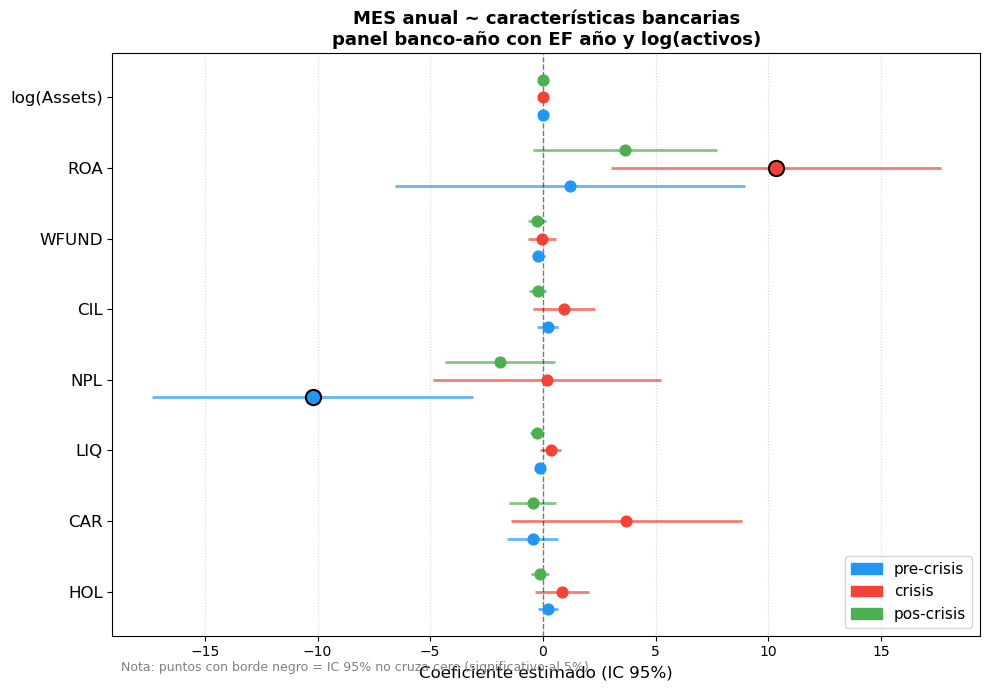

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\coefplot_MES_panel_anual.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# Variables a mostrar (excluimos constante y dummies de año)
variables_plot = [
    "HOL_anual", "CAR_anual", "LIQ_anual", "NPL_anual",
    "CIL_anual", "WFUND_anual", "ROA_anual", "log_assets"
]

# Etiquetas más limpias para el gráfico
etiquetas = {
    "HOL_anual":   "HOL",
    "CAR_anual":   "CAR",
    "LIQ_anual":   "LIQ",
    "NPL_anual":   "NPL",
    "CIL_anual":   "CIL",
    "WFUND_anual": "WFUND",
    "ROA_anual":   "ROA",
    "log_assets":  "log(Assets)"
}

tramos_orden = ["pre-crisis", "crisis", "pos-crisis"]
colores      = {"pre-crisis": "#2196F3", "crisis": "#F44336", "pos-crisis": "#4CAF50"}
offsets      = {"pre-crisis": -0.25, "crisis": 0.0, "pos-crisis": 0.25}

n_vars = len(variables_plot)
y_pos  = np.arange(n_vars)

fig, ax = plt.subplots(figsize=(10, 7))

for tramo in tramos_orden:
    if tramo not in resultados_3:
        continue
    m = resultados_3[tramo]

    coefs  = []
    ci_low = []
    ci_hi  = []
    valid  = []

    for var in variables_plot:
        if var in m.params.index:
            coefs.append(m.params[var])
            ci_low.append(m.conf_int().loc[var, 0])
            ci_hi.append(m.conf_int().loc[var, 1])
            valid.append(True)
        else:
            coefs.append(np.nan)
            ci_low.append(np.nan)
            ci_hi.append(np.nan)
            valid.append(False)

    coefs  = np.array(coefs)
    ci_low = np.array(ci_low)
    ci_hi  = np.array(ci_hi)
    y_off  = y_pos + offsets[tramo]

    # Barras de error (intervalo de confianza al 95%)
    ax.hlines(
        y_off, ci_low, ci_hi,
        color=colores[tramo], linewidth=2, alpha=0.7
    )
    # Puntos de coeficientes
    ax.scatter(
        coefs, y_off,
        color=colores[tramo], s=60, zorder=5, label=tramo
    )
    # Marcar significancia al 5%: punto relleno vs hueco
    for i, (c, lo, hi) in enumerate(zip(coefs, ci_low, ci_hi)):
        if not np.isnan(c):
            sig = not (lo <= 0 <= hi)  # IC no cruza el cero → significativo
            if sig:
                ax.scatter(
                    c, y_off[i],
                    color=colores[tramo], s=120,
                    edgecolors="black", linewidths=1.5, zorder=6
                )

# Línea vertical en 0
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

# Etiquetas del eje Y
ax.set_yticks(y_pos)
ax.set_yticklabels([etiquetas[v] for v in variables_plot], fontsize=12)

# Leyenda
legend_elements = [
    mpatches.Patch(color=colores[t], label=t) for t in tramos_orden
]
ax.legend(handles=legend_elements, fontsize=11, loc="lower right")

# Nota de significancia
ax.text(
    0.01, -0.06,
    "Nota: puntos con borde negro = IC 95% no cruza cero (significativo al 5%)",
    transform=ax.transAxes, fontsize=9, color="gray"
)

ax.set_xlabel("Coeficiente estimado (IC 95%)", fontsize=12)
ax.set_title(
    "MES anual ~ características bancarias\npanel banco-año con EF año y log(activos)",
    fontsize=13, fontweight="bold"
)
ax.grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()

# Guardar
fig_path = out_dir / "coefplot_MES_panel_anual.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig_path}")

   year  mes_medio   mes_p25   mes_p75   mes_min   mes_max  n_bancos
0  1997   0.335483  0.247432  0.416063  0.013159  0.735870        39
1  1998   0.055543 -0.059289  0.175896 -0.362689  0.399944        39
2  1999   0.009252 -0.057558  0.095144 -0.335559  0.323425        39
3  2000  -0.166050 -0.287776 -0.075262 -0.536194  0.337207        39
4  2001   0.147964 -0.111479  0.321391 -0.403160  0.904257        39
5  2002   0.066468 -0.018850  0.125094 -0.402254  1.213333        39
6  2003  -0.027228 -0.126807  0.092516 -0.498601  0.816881        39
7  2004   0.152286  0.060753  0.238729 -0.134436  0.626949        39
8  2005   0.036628 -0.051572  0.119763 -0.203499  0.265864        39
9  2006   0.092442  0.024982  0.125577 -0.161071  0.390432        39


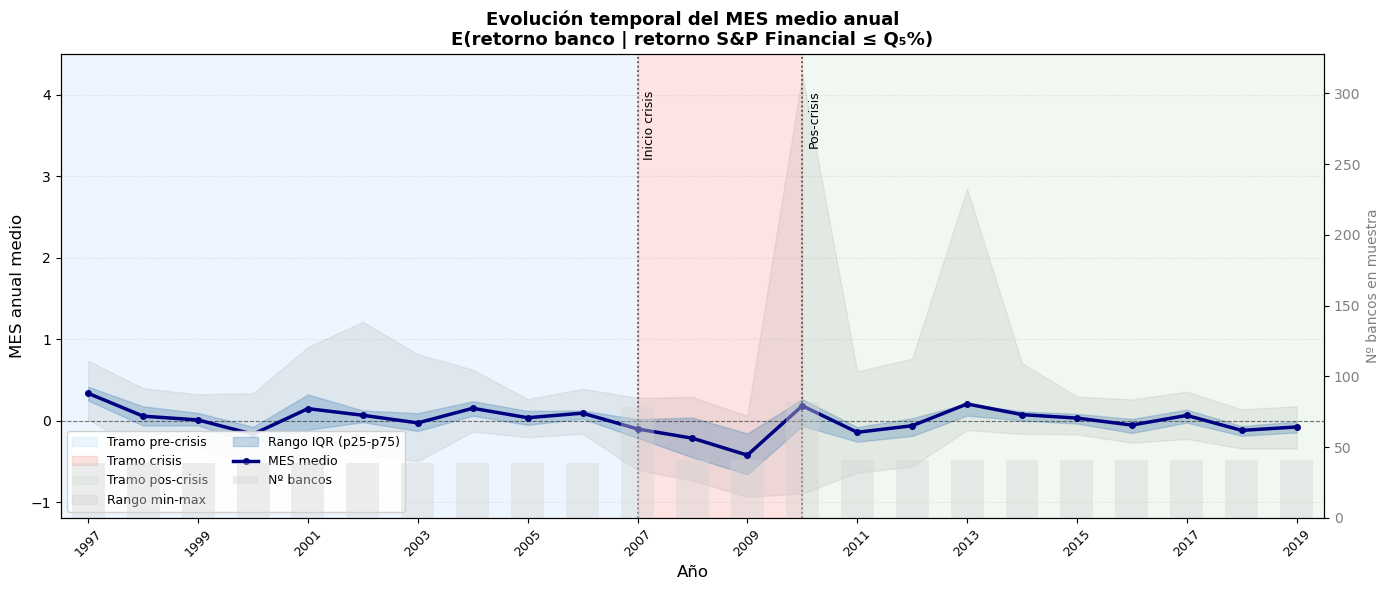

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\evolucion_MES_anual.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. CALCULAR MES MEDIO Y BANDAS POR AÑO ────────────────────────────
# Usamos mes_anual_df (banco-año-tramo) ya calculado antes
mes_evol = (
    mes_anual_df[mes_anual_df["tramo"] != "fuera"]
    .groupby("year")["MES_anual"]
    .agg(
        mes_medio  = "mean",
        mes_p25    = lambda x: x.quantile(0.25),
        mes_p75    = lambda x: x.quantile(0.75),
        mes_min    = "min",
        mes_max    = "max",
        n_bancos   = "count"
    )
    .reset_index()
    .sort_values("year")
)

print(mes_evol.head(10))

# ── 2. GRÁFICO ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

years = mes_evol["year"].values

# Zonas sombreadas por tramo
tramos_zonas = [
    ("pre-crisis", 1996, 2007, "#2196F3", 0.08),
    ("crisis",     2007, 2010, "#F44336", 0.15),
    ("pos-crisis", 2010, 2020, "#4CAF50", 0.08),
]
for nombre, inicio, fin, color, alpha in tramos_zonas:
    ax.axvspan(inicio, fin, color=color, alpha=alpha, label=f"Tramo {nombre}")

# Banda min-max (rango completo)
ax.fill_between(
    years, mes_evol["mes_min"], mes_evol["mes_max"],
    color="gray", alpha=0.12, label="Rango min-max"
)

# Banda intercuartílica (p25-p75)
ax.fill_between(
    years, mes_evol["mes_p25"], mes_evol["mes_p75"],
    color="steelblue", alpha=0.30, label="Rango IQR (p25-p75)"
)

# Línea del MES medio
ax.plot(
    years, mes_evol["mes_medio"],
    color="navy", linewidth=2.5, marker="o", markersize=4,
    label="MES medio", zorder=5
)

# Línea horizontal en 0
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# Líneas verticales en cambio de tramo
for año_cambio, label in [(2007, "Inicio crisis"), (2010, "Pos-crisis")]:
    ax.axvline(año_cambio, color="black", linewidth=1.2,
               linestyle=":", alpha=0.7)
    ax.text(
        año_cambio + 0.1, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] != 0 else 0.3,
        label, fontsize=9, color="black", rotation=90, va="top"
    )

# Eje secundario: número de bancos
ax2 = ax.twinx()
ax2.bar(
    years, mes_evol["n_bancos"],
    color="lightgray", alpha=0.4, width=0.6, label="Nº bancos"
)
ax2.set_ylabel("Nº bancos en muestra", fontsize=10, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax2.set_ylim(0, mes_evol["n_bancos"].max() * 4)  # escalar para no solapar

# Formato eje X
ax.set_xlim(years.min() - 0.5, years.max() + 0.5)
ax.set_xticks(years[::2])  # cada 2 años
ax.set_xticklabels(years[::2], rotation=45, fontsize=9)

# Etiquetas y título
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("MES anual medio", fontsize=12)
ax.set_title(
    "Evolución temporal del MES medio anual\n"
    "E(retorno banco | retorno S&P Financial ≤ Q₅%)",
    fontsize=13, fontweight="bold"
)

# Leyenda combinada
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2, labels1 + labels2,
    loc="lower left", fontsize=9, ncol=2,
    framealpha=0.9
)

ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()

# Guardar
fig_path = out_dir / "evolucion_MES_anual.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig_path}")

Top bancos por Asset_share_100:
   rssd_id  Asset_share_100
0   480228            14.18
1   852218            12.94
2   476810            12.13
3   451965             7.42
4   817824             1.61
5   694904             1.34
6   852320             0.99
7  2736291             0.96
8    35301             0.93
9   233031             0.83


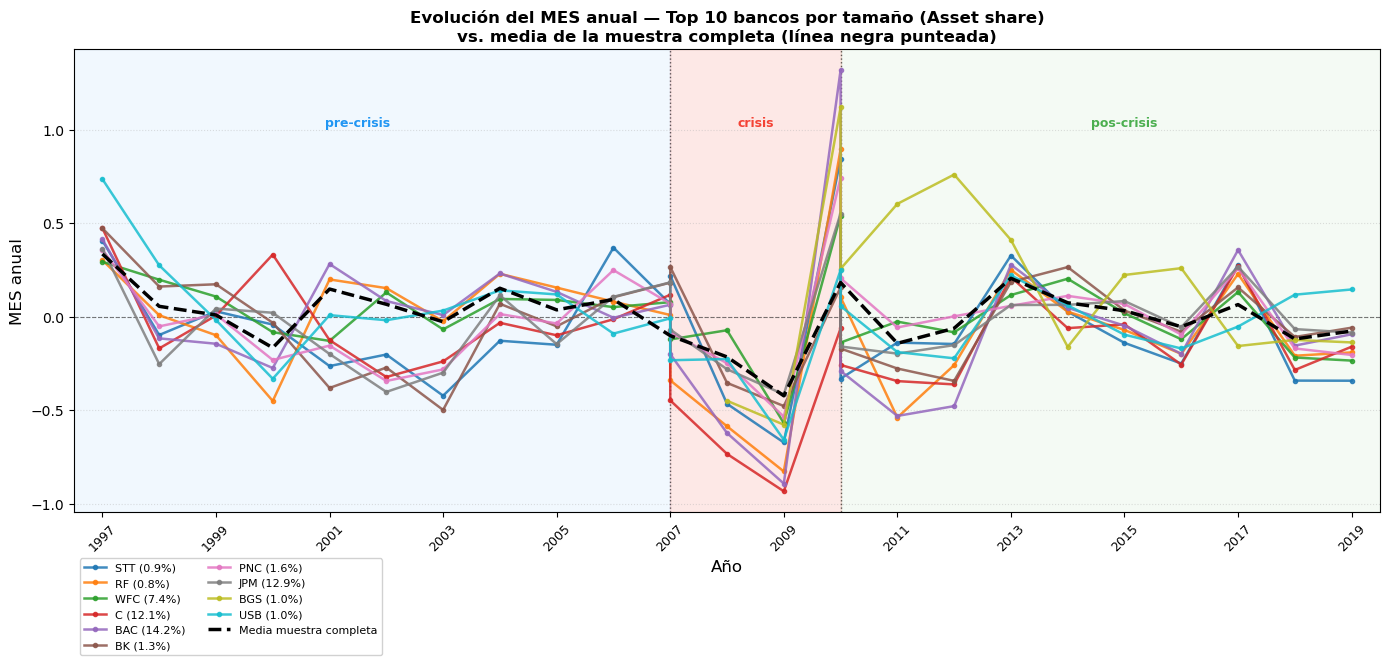

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\MES_top_bancos.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. SELECCIONAR LOS N BANCOS MÁS GRANDES ───────────────────────────
# Usamos Asset_share_100 de banks: tomamos la media de todo el periodo
path_banks = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\indices\bank_list_MES-prices-monthly-1996_2026.csv")
banks_raw  = pd.read_csv(path_banks)
banks_raw["date"] = pd.to_datetime(banks_raw["date"]).apply(lambda d: d.replace(day=1))

# Seleccionar los 10 bancos con mayor Asset_share_100 medio
top_n = 10

ranking = (
    banks_raw.groupby("rssd_id")["Asset_share_100"]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)

top_ids = ranking["rssd_id"].tolist()
print("Top bancos por Asset_share_100:")
print(ranking)

# ── 2. EXTRAER MES ANUAL PARA ESOS BANCOS ─────────────────────────────
# mes_anual_df ya está calculado (banco-año-tramo)
mes_top = (
    mes_anual_df[mes_anual_df["rssd_id"].isin(top_ids)]
    .sort_values(["rssd_id", "year"])
)

# Añadir ticket si está disponible (para etiquetar las líneas)
ticket_map = (
    banks_raw[["rssd_id", "ticket"]]
    .drop_duplicates("rssd_id")
    .set_index("rssd_id")["ticket"]
    .to_dict()
)

mes_top["label"] = mes_top["rssd_id"].map(
    lambda x: ticket_map.get(x, str(x))
)

# ── 3. GRÁFICO ─────────────────────────────────────────────────────────
colores_banco = cm.tab10(np.linspace(0, 1, top_n))

fig, ax = plt.subplots(figsize=(14, 7))

# Zonas de tramo
tramos_zonas = [
    ("pre-crisis", 1996, 2007, "#2196F3", 0.06),
    ("crisis",     2007, 2010, "#F44336", 0.12),
    ("pos-crisis", 2010, 2020, "#4CAF50", 0.06),
]
for nombre, inicio, fin, color, alpha in tramos_zonas:
    ax.axvspan(inicio, fin, color=color, alpha=alpha)

# Etiquetas de tramo en la parte superior
for nombre, inicio, fin, color, _ in tramos_zonas:
    ax.text(
        (inicio + fin) / 2, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.5,
        nombre, ha="center", fontsize=9, color=color,
        fontweight="bold", va="bottom"
    )

# Línea horizontal en 0
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# Líneas verticales en cambio de tramo
for año_cambio in [2007, 2010]:
    ax.axvline(año_cambio, color="black", linewidth=1.0, linestyle=":", alpha=0.6)

# Línea por cada banco
for i, (rssd_id, grp) in enumerate(mes_top.groupby("rssd_id")):
    label = ticket_map.get(rssd_id, str(rssd_id))
    asset = ranking[ranking["rssd_id"] == rssd_id]["Asset_share_100"].values
    asset_str = f" ({asset[0]:.1f}%)" if len(asset) > 0 else ""

    ax.plot(
        grp["year"], grp["MES_anual"],
        color=colores_banco[i],
        linewidth=1.8,
        marker="o", markersize=3,
        label=f"{label}{asset_str}",
        alpha=0.85
    )

# MES medio del conjunto (línea de referencia)
mes_medio_anual = (
    mes_anual_df.groupby("year")["MES_anual"]
    .mean()
    .reset_index()
)
ax.plot(
    mes_medio_anual["year"], mes_medio_anual["MES_anual"],
    color="black", linewidth=2.5, linestyle="--",
    label="Media muestra completa", zorder=10
)

# Formato
all_years = mes_top["year"].unique()
ax.set_xlim(all_years.min() - 0.5, all_years.max() + 0.5)
ax.set_xticks(sorted(all_years)[::2])
ax.set_xticklabels(sorted(all_years)[::2], rotation=45, fontsize=9)
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("MES anual", fontsize=12)
ax.set_title(
    f"Evolución del MES anual — Top {top_n} bancos por tamaño (Asset share)\n"
    "vs. media de la muestra completa (línea negra punteada)",
    fontsize=12, fontweight="bold"
)
ax.legend(
    fontsize=8, ncol=2, loc="lower left",
    framealpha=0.9, bbox_to_anchor=(0.0, -0.32)
)
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()

# Guardar
fig_path = out_dir / "MES_top_bancos.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig_path}")

Dimensiones heatmap: (41, 23) (bancos × años)


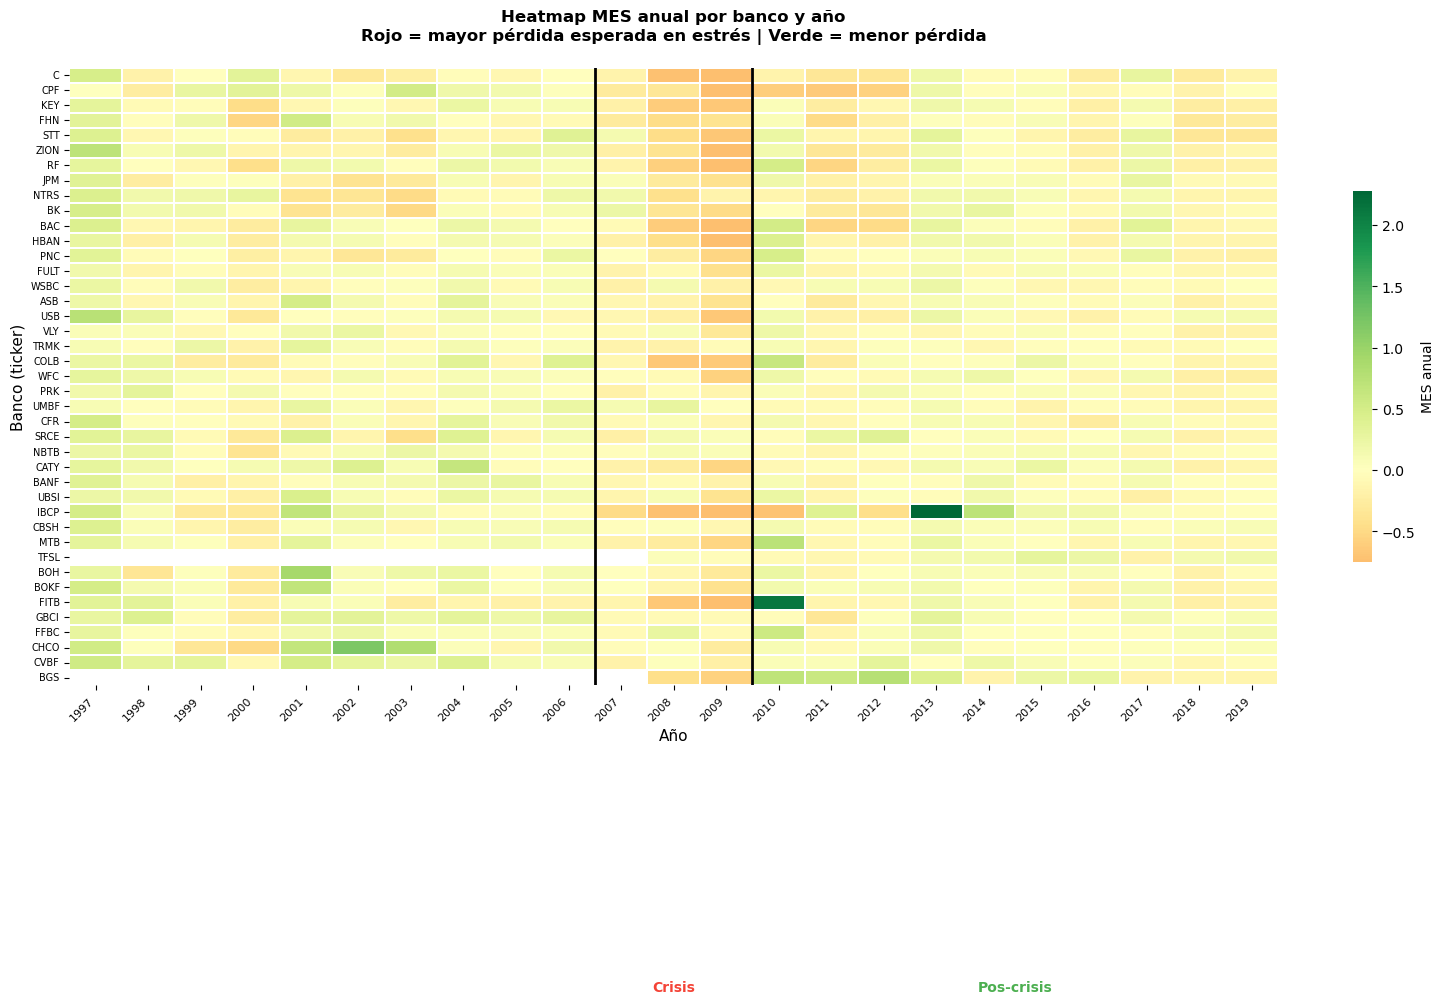

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\heatmap_MES_banco_anual.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. PREPARAR MATRIZ banco × año ────────────────────────────────────
# Usamos todos los bancos con al menos N años de datos
min_años = 5  # ajusta según quieras más o menos bancos

# Contar años disponibles por banco
años_por_banco = mes_anual_df.groupby("rssd_id")["year"].nunique()
bancos_validos = años_por_banco[años_por_banco >= min_años].index

mes_heat = mes_anual_df[mes_anual_df["rssd_id"].isin(bancos_validos)].copy()

# Usar ticker como etiqueta si está disponible
mes_heat["label"] = mes_heat["rssd_id"].map(
    lambda x: ticket_map.get(x, str(x))
)

# Ordenar bancos por MES medio (de mayor riesgo = más negativo, a menor)
orden_bancos = (
    mes_heat.groupby("label")["MES_anual"]
    .mean()
    .sort_values(ascending=True)   # más negativo arriba
    .index.tolist()
)

# Crear tabla pivote: filas = bancos, columnas = años
pivot = (
    mes_heat
    .pivot_table(index="label", columns="year", values="MES_anual", aggfunc="mean")
    .reindex(orden_bancos)
)

print(f"Dimensiones heatmap: {pivot.shape} (bancos × años)")

# ── 2. HEATMAP ─────────────────────────────────────────────────────────
n_bancos, n_años = pivot.shape
alto = max(8, n_bancos * 0.28)   # altura dinámica según nº de bancos

fig, ax = plt.subplots(figsize=(16, alto))

sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdYlGn",          # rojo = MES muy negativo (riesgo alto), verde = MES positivo
    center=0,
    linewidths=0.3,
    linecolor="white",
    annot=False,            # True si quieres valores en cada celda (lento con muchos bancos)
    fmt=".2f",
    cbar_kws={
        "label": "MES anual",
        "shrink": 0.6,
        "orientation": "vertical"
    },
    vmin=pivot.values[~np.isnan(pivot.values)].min() * 0.8,
    vmax=pivot.values[~np.isnan(pivot.values)].max() * 0.8,
    mask=pivot.isna()       # celdas sin dato aparecen en blanco
)

# Líneas verticales en cambio de tramo
años_columnas = list(pivot.columns)
for año_cambio in [2007, 2010]:
    if año_cambio in años_columnas:
        pos = años_columnas.index(año_cambio)
        ax.axvline(pos, color="black", linewidth=2.0, linestyle="-")

# Etiquetas de tramo encima del heatmap
tramos_heat = [
    ("Pre-crisis", 1996, 2007, "#2196F3"),
    ("Crisis",     2007, 2010, "#F44336"),
    ("Pos-crisis", 2010, 2020, "#4CAF50"),
]
for nombre, inicio, fin, color in tramos_heat:
    if inicio in años_columnas and fin in años_columnas:
        x0 = años_columnas.index(inicio)
        x1 = años_columnas.index(fin)
    elif inicio in años_columnas:
        x0 = años_columnas.index(inicio)
        x1 = len(años_columnas)
    else:
        continue
    ax.annotate(
        nombre,
        xy=((x0 + x1) / 2, -0.5),
        xycoords=("data", "axes fraction"),
        ha="center", va="bottom",
        fontsize=10, color=color, fontweight="bold",
        annotation_clip=False
    )

# Formato
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Banco (ticker)", fontsize=11)
ax.set_title(
    "Heatmap MES anual por banco y año\n"
    "Rojo = mayor pérdida esperada en estrés | Verde = menor pérdida",
    fontsize=12, fontweight="bold", pad=20
)

# Rotar etiquetas del eje X
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha="right", fontsize=8
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=7
)

plt.tight_layout()

# Guardar
fig_path = out_dir / "heatmap_MES_banco_anual.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig_path}")